In [4]:
import pandas as pd
import numpy as np

from scipy.stats import (
    ks_2samp,
    chi2_contingency,
    wasserstein_distance
)

import matplotlib.pyplot as plt


In [5]:
np.random.seed(42)

n_samples = 1000

reference_data = pd.DataFrame({
    "transaction_amount": np.random.normal(
        loc=2000,
        scale=500,
        size=n_samples
    ),

    "customer_age": np.random.normal(
        loc=35,
        scale=10,
        size=n_samples
    ),

    "transaction_frequency": np.random.poisson(
        lam=5,
        size=n_samples
    ),

    "payment_method": np.random.choice(
        ["UPI", "Card", "Cash"],
        size=n_samples,
        p=[0.60, 0.30, 0.10]
    )
})


current_data = pd.DataFrame({
    "transaction_amount": np.random.normal(
        loc=5000,
        scale=800,
        size=n_samples
    ),

    "customer_age": np.random.normal(
        loc=35,
        scale=10,
        size=n_samples
    ),

    "transaction_frequency": np.random.poisson(
        lam=5,
        size=n_samples
    ),

    "payment_method": np.random.choice(
        ["UPI", "Card", "Cash"],
        size=n_samples,
        p=[0.30, 0.55, 0.15]
    )
})

In [6]:
print("Reference Data:")
display(reference_data.head())

print("\nReference Data Shape:")
print(reference_data.shape)

print("\nCurrent Data Shape:")
print(current_data.shape)

print("\nData Types:")
print(reference_data.dtypes)

Reference Data:


,transaction_amount,customer_age,transaction_frequency,payment_method
0,2248.357077,48.993554,3,UPI
1,1930.867849,44.246337,6,UPI
2,2323.844269,35.596304,4,UPI
3,2761.514928,28.530632,4,UPI
4,1882.923313,41.982233,8,UPI



Reference Data Shape:
(1000, 4)

Current Data Shape:
(1000, 4)

Data Types:
transaction_amount       float64
customer_age             float64
transaction_frequency      int64
payment_method               str
dtype: object


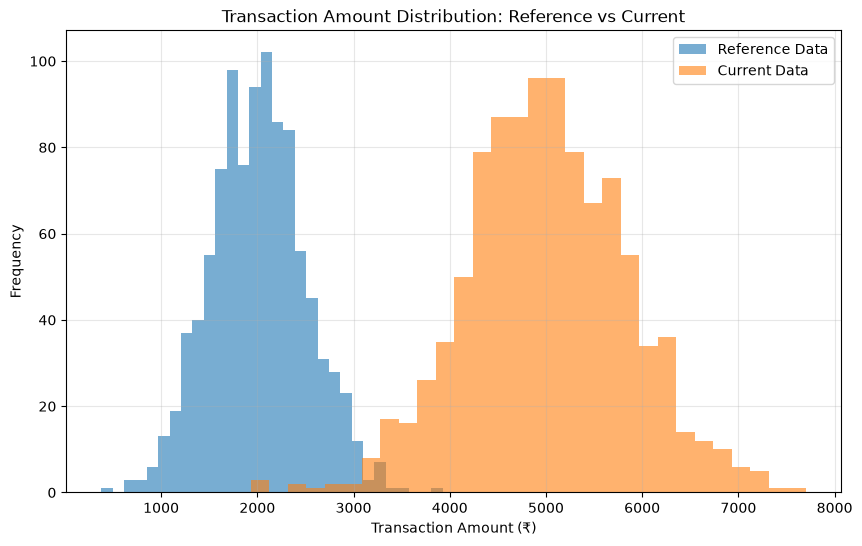

In [7]:
plt.figure(figsize=(10, 6))

plt.hist(
    reference_data["transaction_amount"],
    bins=30,
    alpha=0.6,
    label="Reference Data"
)

plt.hist(
    current_data["transaction_amount"],
    bins=30,
    alpha=0.6,
    label="Current Data"
)

plt.title("Transaction Amount Distribution: Reference vs Current")
plt.xlabel("Transaction Amount (₹)")
plt.ylabel("Frequency")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [8]:
def detect_numerical_drift(
    reference,
    current,
    threshold=0.05
):
    """
    Detect drift in a numerical feature.

    Uses:
    1. Kolmogorov-Smirnov test
    2. Wasserstein distance
    3. Normalized Wasserstein distance
    """

    # KS test
    ks_statistic, p_value = ks_2samp(
        reference,
        current
    )

    # Wasserstein distance
    wasserstein = wasserstein_distance(
        reference,
        current
    )

    # Standard deviation of reference data
    reference_std = reference.std()

    # Normalize the Wasserstein distance
    if reference_std != 0:
        normalized_magnitude = (
            wasserstein / reference_std
        )
    else:
        normalized_magnitude = 0

    # Statistical drift decision
    if p_value < threshold:
        drift_detected = True
    else:
        drift_detected = False

    return {
        "statistic": ks_statistic,
        "p_value": p_value,
        "magnitude": wasserstein,
        "normalized_magnitude": normalized_magnitude,
        "drift_detected": drift_detected
    }

In [9]:
def detect_categorical_drift(
    reference,
    current,
    threshold=0.05
):
    """
    Detect drift in a categorical feature
    using the Chi-Square test.
    """

    # Count each category
    reference_counts = reference.value_counts()
    current_counts = current.value_counts()

    # Combine all categories from both datasets
    categories = (
        set(reference_counts.index)
        | set(current_counts.index)
    )

    # Make both datasets contain the same categories
    reference_counts = reference_counts.reindex(
        categories,
        fill_value=0
    )

    current_counts = current_counts.reindex(
        categories,
        fill_value=0
    )

    # Create contingency table
    contingency_table = pd.DataFrame({
        "reference": reference_counts,
        "current": current_counts
    })

    # Chi-Square test
    chi2, p_value, degrees_of_freedom, expected = (
        chi2_contingency(contingency_table)
    )

    # Statistical drift decision
    if p_value < threshold:
        drift_detected = True
    else:
        drift_detected = False

    return {
        "statistic": chi2,
        "p_value": p_value,
        "drift_detected": drift_detected
    }

In [10]:
def classify_numerical_severity(
    p_value,
    normalized_magnitude,
    threshold=0.05
):
    """
    Classify numerical drift severity.

    These magnitude thresholds are initial
    project thresholds, not universal standards.
    """

    # No statistically significant drift
    if p_value >= threshold:
        return "NO_DRIFT"

    # Statistically significant but very small movement
    if normalized_magnitude < 0.1:
        return "LOW"

    # Noticeable movement
    elif normalized_magnitude < 0.5:
        return "MEDIUM"

    # Large movement
    else:
        return "HIGH"

In [11]:
def detect_dataset_drift(
    reference_data,
    current_data,
    threshold=0.05
):
    """
    Detect drift across every feature in a dataset.

    Automatically selects:
    - KS Test + Wasserstein for numerical features
    - Chi-Square Test for categorical features
    """

    results = []

    # Loop through every reference feature
    for column in reference_data.columns:

        reference = reference_data[column]
        current = current_data[column]

        # Numerical feature
        if pd.api.types.is_numeric_dtype(reference):

            drift_result = detect_numerical_drift(
                reference,
                current,
                threshold
            )

            severity = classify_numerical_severity(
                drift_result["p_value"],
                drift_result["normalized_magnitude"],
                threshold
            )

            result = {
                "feature": column,
                "test": "KS Test",
                "statistic": drift_result["statistic"],
                "p_value": drift_result["p_value"],
                "magnitude": drift_result["magnitude"],
                "normalized_magnitude": drift_result[
                    "normalized_magnitude"
                ],
                "drift_detected": drift_result[
                    "drift_detected"
                ],
                "severity": severity
            }

        # Categorical feature
        else:

            drift_result = detect_categorical_drift(
                reference,
                current,
                threshold
            )

            result = {
                "feature": column,
                "test": "Chi-Square Test",
                "statistic": drift_result["statistic"],
                "p_value": drift_result["p_value"],
                "magnitude": np.nan,
                "normalized_magnitude": np.nan,
                "drift_detected": drift_result[
                    "drift_detected"
                ],
                "severity": (
                    "HIGH"
                    if drift_result["drift_detected"]
                    else "NO_DRIFT"
                )
            }

        results.append(result)

    return pd.DataFrame(results)

In [12]:
drift_report = detect_dataset_drift(
    reference_data,
    current_data
)

display(drift_report)


,feature,test,statistic,p_value,magnitude,normalized_magnitude,drift_detected,severity
0,transaction_amount,KS Test,0.977000,0.000000e+00,2996.725027,6.120662,True,HIGH
1,customer_age,KS Test,0.031000,7.228252e-01,0.677254,0.067898,False,NO_DRIFT
2,transaction_frequency,KS Test,0.034000,6.101665e-01,0.185000,0.088420,False,NO_DRIFT
3,payment_method,Chi-Square Test,244.755489,7.112476e-54,NaN,NaN,True,HIGH


In [14]:
np.random.seed(200)

subtle_drift_data = pd.DataFrame({

    "transaction_amount": np.random.normal(
        loc=2200,
        scale=500,
        size=n_samples
    ),

    "customer_age": np.random.normal(
        loc=35,
        scale=10,
        size=n_samples
    ),

    "transaction_frequency": np.random.poisson(
        lam=5,
        size=n_samples
    ),

    "payment_method": np.random.choice(
        ["UPI", "Card", "Cash"],
        size=n_samples,
        p=[0.60, 0.30, 0.10]
    )
})


subtle_drift_report = detect_dataset_drift(
    reference_data,
    subtle_drift_data
)

display(subtle_drift_report)

,feature,test,statistic,p_value,magnitude,normalized_magnitude,drift_detected,severity
0,transaction_amount,KS Test,0.166000,1.923533e-12,176.526193,0.360546,True,MEDIUM
1,customer_age,KS Test,0.041000,3.701202e-01,0.618321,0.061990,False,NO_DRIFT
2,transaction_frequency,KS Test,0.024000,9.357699e-01,0.131000,0.062611,False,NO_DRIFT
3,payment_method,Chi-Square Test,5.277803,7.143972e-02,NaN,NaN,False,NO_DRIFT


In [25]:
# ============================================
# CELL 11 — NO-DRIFT VALIDATION
# ============================================

np.random.seed(100)

no_drift_data = pd.DataFrame({

    "transaction_amount": np.random.normal(
        loc=2000,
        scale=500,
        size=n_samples
    ),

    "customer_age": np.random.normal(
        loc=35,
        scale=10,
        size=n_samples
    ),

    "transaction_frequency": np.random.poisson(
        lam=5,
        size=n_samples
    ),

    "payment_method": np.random.choice(
        ["UPI", "Card", "Cash"],
        size=n_samples,
        p=[0.60, 0.30, 0.10]
    )
})


no_drift_report = detect_dataset_drift(
    reference_data,
    no_drift_data
)


print("NO-DRIFT VALIDATION REPORT")
print("=" * 60)

display(no_drift_report)

NO-DRIFT VALIDATION REPORT


,feature,test,statistic,p_value,magnitude,normalized_magnitude,drift_detected,severity
0,transaction_amount,KS Test,0.037000,0.500567,32.099680,0.065562,False,NO_DRIFT
1,customer_age,KS Test,0.049000,0.181165,0.728131,0.072999,False,NO_DRIFT
2,transaction_frequency,KS Test,0.023000,0.954219,0.093000,0.044449,False,NO_DRIFT
3,payment_method,Chi-Square Test,0.777528,0.677894,NaN,NaN,False,NO_DRIFT


In [26]:
# ============================================
# CELL 12 — STRONG-DRIFT VALIDATION
# ============================================

strong_drift_report = detect_dataset_drift(
    reference_data,
    current_data
)


print("STRONG-DRIFT VALIDATION REPORT")
print("=" * 60)

display(strong_drift_report)


# --------------------------------------------
# Validate expected drift behavior
# --------------------------------------------

drifted_features = strong_drift_report.loc[
    strong_drift_report["drift_detected"],
    "feature"
].tolist()


print("\nDetected Drift Features:")
print(drifted_features)


assert "transaction_amount" in drifted_features, (
    "Expected transaction_amount drift was not detected."
)

assert "payment_method" in drifted_features, (
    "Expected payment_method drift was not detected."
)


print("\nValidation Status: PASSED")

STRONG-DRIFT VALIDATION REPORT


,feature,test,statistic,p_value,magnitude,normalized_magnitude,drift_detected,severity
0,transaction_amount,KS Test,0.977000,0.000000e+00,2996.725027,6.120662,True,HIGH
1,customer_age,KS Test,0.031000,7.228252e-01,0.677254,0.067898,False,NO_DRIFT
2,transaction_frequency,KS Test,0.034000,6.101665e-01,0.185000,0.088420,False,NO_DRIFT
3,payment_method,Chi-Square Test,244.755489,7.112476e-54,NaN,NaN,True,HIGH



Detected Drift Features:
['transaction_amount', 'payment_method']

Validation Status: PASSED


In [27]:
# ============================================
# CELL 13 — MISSING VALUES + DATA VALIDATION
# ============================================

def validate_dataset_pair(
    reference_data,
    current_data,
    min_samples=30
):
    """
    Validate reference and current datasets
    before running statistical drift tests.

    Checks:

    1. Empty datasets
    2. Missing columns
    3. Extra columns
    4. Data type mismatches
    5. Small sample sizes
    6. Missing values
    7. Constant features
    """

    validation = {
        "reference_empty": reference_data.empty,
        "current_empty": current_data.empty,
        "missing_columns": [],
        "extra_columns": [],
        "dtype_mismatches": {},
        "small_reference_features": [],
        "small_current_features": [],
        "reference_missing_values": {},
        "current_missing_values": {},
        "reference_constant_features": [],
        "current_constant_features": []
    }

    # ----------------------------------------
    # Empty dataset check
    # ----------------------------------------

    if reference_data.empty:
        validation["reference_empty"] = True

    if current_data.empty:
        validation["current_empty"] = True

    # ----------------------------------------
    # Column comparison
    # ----------------------------------------

    reference_columns = set(reference_data.columns)
    current_columns = set(current_data.columns)

    validation["missing_columns"] = sorted(
        reference_columns - current_columns
    )

    validation["extra_columns"] = sorted(
        current_columns - reference_columns
    )

    # ----------------------------------------
    # Check shared columns
    # ----------------------------------------

    shared_columns = (
        reference_columns & current_columns
    )

    for column in sorted(shared_columns):

        reference_dtype = reference_data[column].dtype
        current_dtype = current_data[column].dtype

        if reference_dtype != current_dtype:

            validation["dtype_mismatches"][column] = {
                "reference": str(reference_dtype),
                "current": str(current_dtype)
            }

    # ----------------------------------------
    # Missing-value checks
    # ----------------------------------------

    for column in reference_data.columns:

        missing_count = reference_data[column].isna().sum()

        if missing_count > 0:

            validation["reference_missing_values"][column] = {
                "count": int(missing_count),
                "rate": float(
                    missing_count / len(reference_data)
                )
            }

    for column in current_data.columns:

        missing_count = current_data[column].isna().sum()

        if missing_count > 0:

            validation["current_missing_values"][column] = {
                "count": int(missing_count),
                "rate": float(
                    missing_count / len(current_data)
                )
            }

    # ----------------------------------------
    # Small sample check
    # ----------------------------------------

    for column in reference_data.columns:

        non_null_count = reference_data[column].notna().sum()

        if non_null_count < min_samples:

            validation["small_reference_features"].append(
                column
            )

    for column in current_data.columns:

        non_null_count = current_data[column].notna().sum()

        if non_null_count < min_samples:

            validation["small_current_features"].append(
                column
            )

    # ----------------------------------------
    # Constant feature check
    # ----------------------------------------

    for column in reference_data.columns:

        if reference_data[column].nunique(
            dropna=True
        ) <= 1:

            validation[
                "reference_constant_features"
            ].append(column)

    for column in current_data.columns:

        if current_data[column].nunique(
            dropna=True
        ) <= 1:

            validation[
                "current_constant_features"
            ].append(column)

    return validation


# --------------------------------------------
# Create data containing missing values
# --------------------------------------------

missing_value_data = subtle_drift_data.copy()

missing_value_data.loc[
    0:49,
    "transaction_amount"
] = np.nan

missing_value_data.loc[
    100:129,
    "customer_age"
] = np.nan


# --------------------------------------------
# Run validation
# --------------------------------------------

missing_value_validation = validate_dataset_pair(
    reference_data,
    missing_value_data
)


print("MISSING-VALUE VALIDATION")
print("=" * 60)

print("\nReference Missing Values:")
print(
    missing_value_validation[
        "reference_missing_values"
    ]
)

print("\nCurrent Missing Values:")
print(
    missing_value_validation[
        "current_missing_values"
    ]
)

MISSING-VALUE VALIDATION

Reference Missing Values:
{}

Current Missing Values:
{'transaction_amount': {'count': 50, 'rate': 0.05}, 'customer_age': {'count': 30, 'rate': 0.03}}


In [28]:
# ============================================
# CELL 14 — CONSTANT FEATURE HANDLING
# ============================================

constant_feature_data = reference_data.copy()

constant_feature_data[
    "transaction_frequency"
] = 5


constant_validation = validate_dataset_pair(
    reference_data,
    constant_feature_data
)


print("CONSTANT FEATURE VALIDATION")
print("=" * 60)

print("\nReference Constant Features:")
print(
    constant_validation[
        "reference_constant_features"
    ]
)

print("\nCurrent Constant Features:")
print(
    constant_validation[
        "current_constant_features"
    ]
)

CONSTANT FEATURE VALIDATION

Reference Constant Features:
[]

Current Constant Features:
['transaction_frequency']


In [29]:
# ============================================
# CELL 15 — MISSING COLUMN VALIDATION
# ============================================

missing_column_data = current_data.drop(
    columns=["customer_age"]
)


missing_column_validation = validate_dataset_pair(
    reference_data,
    missing_column_data
)


print("MISSING COLUMN VALIDATION")
print("=" * 60)

print("\nMissing Columns:")
print(
    missing_column_validation[
        "missing_columns"
    ]
)


assert "customer_age" in (
    missing_column_validation[
        "missing_columns"
    ]
)


print("\nValidation Status: PASSED")

MISSING COLUMN VALIDATION

Missing Columns:
['customer_age']

Validation Status: PASSED


In [30]:
# ============================================
# CELL 16 — EXTRA COLUMN VALIDATION
# ============================================

extra_column_data = current_data.copy()

extra_column_data["device_type"] = np.random.choice(
    ["Mobile", "Desktop", "Tablet"],
    size=len(extra_column_data)
)


extra_column_validation = validate_dataset_pair(
    reference_data,
    extra_column_data
)


print("EXTRA COLUMN VALIDATION")
print("=" * 60)

print("\nExtra Columns:")
print(
    extra_column_validation[
        "extra_columns"
    ]
)


assert "device_type" in (
    extra_column_validation[
        "extra_columns"
    ]
)


print("\nValidation Status: PASSED")

EXTRA COLUMN VALIDATION

Extra Columns:
['device_type']

Validation Status: PASSED


In [31]:
# ============================================
# CELL 17 — SCHEMA / DATA-TYPE MISMATCH
# ============================================

schema_mismatch_data = current_data.copy()

schema_mismatch_data[
    "transaction_amount"
] = schema_mismatch_data[
    "transaction_amount"
].astype(str)


schema_validation = validate_dataset_pair(
    reference_data,
    schema_mismatch_data
)


print("SCHEMA / DATA-TYPE VALIDATION")
print("=" * 60)

print("\nData-Type Mismatches:")

for column, mismatch in (
    schema_validation[
        "dtype_mismatches"
    ].items()
):

    print(f"\nFeature: {column}")
    print(
        f"Reference dtype: "
        f"{mismatch['reference']}"
    )
    print(
        f"Current dtype: "
        f"{mismatch['current']}"
    )


assert "transaction_amount" in (
    schema_validation[
        "dtype_mismatches"
    ]
)


print("\nValidation Status: PASSED")

SCHEMA / DATA-TYPE VALIDATION

Data-Type Mismatches:

Feature: transaction_amount
Reference dtype: float64
Current dtype: str

Validation Status: PASSED


In [32]:
# ============================================
# CELL 18 — EMPTY DATASET VALIDATION
# ============================================

empty_current_data = current_data.iloc[0:0].copy()


empty_validation = validate_dataset_pair(
    reference_data,
    empty_current_data
)


print("EMPTY DATASET VALIDATION")
print("=" * 60)

print(
    "\nReference dataset empty:",
    empty_validation["reference_empty"]
)

print(
    "Current dataset empty:",
    empty_validation["current_empty"]
)


assert empty_validation["current_empty"] is True


print("\nValidation Status: PASSED")

EMPTY DATASET VALIDATION

Reference dataset empty: False
Current dataset empty: True

Validation Status: PASSED


In [33]:
# ============================================
# CELL 19 — SMALL SAMPLE VALIDATION
# ============================================

small_reference_data = reference_data.head(10).copy()

small_current_data = current_data.head(10).copy()


small_sample_validation = validate_dataset_pair(
    small_reference_data,
    small_current_data,
    min_samples=30
)


print("SMALL SAMPLE VALIDATION")
print("=" * 60)

print("\nSmall Reference Features:")
print(
    small_sample_validation[
        "small_reference_features"
    ]
)

print("\nSmall Current Features:")
print(
    small_sample_validation[
        "small_current_features"
    ]
)


assert len(
    small_sample_validation[
        "small_reference_features"
    ]
) > 0


assert len(
    small_sample_validation[
        "small_current_features"
    ]
) > 0


print("\nValidation Status: PASSED")

SMALL SAMPLE VALIDATION

Small Reference Features:
['transaction_amount', 'customer_age', 'transaction_frequency', 'payment_method']

Small Current Features:
['transaction_amount', 'customer_age', 'transaction_frequency', 'payment_method']

Validation Status: PASSED


In [34]:
# ============================================
# CELL 20 — FINAL VALIDATION SUMMARY
# ============================================

final_validation = validate_dataset_pair(
    reference_data,
    current_data
)


print("DATA VALIDATION SUMMARY")
print("=" * 60)


print("\n1. EMPTY DATASET")
print("-" * 60)

print(
    "Reference empty:",
    final_validation["reference_empty"]
)

print(
    "Current empty:",
    final_validation["current_empty"]
)


print("\n2. MISSING COLUMNS")
print("-" * 60)

print(
    final_validation["missing_columns"]
)


print("\n3. EXTRA COLUMNS")
print("-" * 60)

print(
    final_validation["extra_columns"]
)


print("\n4. DATA-TYPE MISMATCHES")
print("-" * 60)

print(
    final_validation["dtype_mismatches"]
)


print("\n5. REFERENCE MISSING VALUES")
print("-" * 60)

print(
    final_validation[
        "reference_missing_values"
    ]
)


print("\n6. CURRENT MISSING VALUES")
print("-" * 60)

print(
    final_validation[
        "current_missing_values"
    ]
)


print("\n7. SMALL REFERENCE FEATURES")
print("-" * 60)

print(
    final_validation[
        "small_reference_features"
    ]
)


print("\n8. SMALL CURRENT FEATURES")
print("-" * 60)

print(
    final_validation[
        "small_current_features"
    ]
)


print("\n9. CONSTANT REFERENCE FEATURES")
print("-" * 60)

print(
    final_validation[
        "reference_constant_features"
    ]
)


print("\n10. CONSTANT CURRENT FEATURES")
print("-" * 60)

print(
    final_validation[
        "current_constant_features"
    ]
)


print("\n" + "=" * 60)
print("VALIDATION LAYER COMPLETE")
print("=" * 60)

DATA VALIDATION SUMMARY

1. EMPTY DATASET
------------------------------------------------------------
Reference empty: False
Current empty: False

2. MISSING COLUMNS
------------------------------------------------------------
[]

3. EXTRA COLUMNS
------------------------------------------------------------
[]

4. DATA-TYPE MISMATCHES
------------------------------------------------------------
{}

5. REFERENCE MISSING VALUES
------------------------------------------------------------
{}

6. CURRENT MISSING VALUES
------------------------------------------------------------
{}

7. SMALL REFERENCE FEATURES
------------------------------------------------------------
[]

8. SMALL CURRENT FEATURES
------------------------------------------------------------
[]

9. CONSTANT REFERENCE FEATURES
------------------------------------------------------------
[]

10. CONSTANT CURRENT FEATURES
------------------------------------------------------------
[]

VALIDATION LAYER COMPLETE


In [39]:
# ============================================
# CELL 21 — CATEGORICAL DRIFT MAGNITUDE
# ============================================

def calculate_total_variation_distance(
    reference,
    current
):
    """
    Calculate Total Variation Distance (TVD)
    between two categorical distributions.

    TVD ranges from:

        0 = identical distributions

        1 = completely different distributions
    """

    reference_distribution = (
        reference.value_counts(
            normalize=True
        )
    )

    current_distribution = (
        current.value_counts(
            normalize=True
        )
    )

    # ----------------------------------------
    # Combine all possible categories
    # ----------------------------------------

    categories = (
        set(reference_distribution.index)
        | set(current_distribution.index)
    )

    reference_distribution = (
        reference_distribution.reindex(
            categories,
            fill_value=0
        )
    )

    current_distribution = (
        current_distribution.reindex(
            categories,
            fill_value=0
        )
    )

    # ----------------------------------------
    # Calculate TVD
    # ----------------------------------------

    tvd = 0.5 * np.sum(
        np.abs(
            reference_distribution
            - current_distribution
        )
    )

    return float(tvd)


# --------------------------------------------
# Test categorical magnitude
# --------------------------------------------

payment_method_tvd = calculate_total_variation_distance(
    reference_data["payment_method"],
    current_data["payment_method"]
)


print("Payment Method TVD:")
print(payment_method_tvd)

Payment Method TVD:
0.348


In [40]:
# ============================================
# CELL 22 — CATEGORICAL MAGNITUDE COMPARISON
# ============================================

no_drift_tvd = calculate_total_variation_distance(
    reference_data["payment_method"],
    no_drift_data["payment_method"]
)


subtle_drift_tvd = calculate_total_variation_distance(
    reference_data["payment_method"],
    subtle_drift_data["payment_method"]
)


strong_drift_tvd = calculate_total_variation_distance(
    reference_data["payment_method"],
    current_data["payment_method"]
)


categorical_magnitude_report = pd.DataFrame({

    "scenario": [
        "No Drift",
        "Subtle Drift",
        "Strong Drift"
    ],

    "TVD": [
        no_drift_tvd,
        subtle_drift_tvd,
        strong_drift_tvd
    ]
})


display(categorical_magnitude_report)

,scenario,TVD
0,No Drift,0.019
1,Subtle Drift,0.048
2,Strong Drift,0.348


In [41]:
# ============================================
# CELL 23 — CATEGORICAL SEVERITY
# ============================================

def classify_categorical_severity(
    p_value,
    tvd,
    threshold=0.05
):
    """
    Classify categorical drift severity.

    Statistical significance:
        p-value < threshold

    Practical magnitude:
        TVD < 0.05  -> LOW
        TVD < 0.20  -> MEDIUM
        TVD >= 0.20 -> HIGH
    """

    # ----------------------------------------
    # No statistically significant drift
    # ----------------------------------------

    if p_value >= threshold:
        return "NO_DRIFT"

    # ----------------------------------------
    # Statistically significant but
    # practically very small
    # ----------------------------------------

    if tvd < 0.05:
        return "LOW"

    # ----------------------------------------
    # Moderate distribution movement
    # ----------------------------------------

    elif tvd < 0.20:
        return "MEDIUM"

    # ----------------------------------------
    # Large distribution movement
    # ----------------------------------------

    else:
        return "HIGH"


# --------------------------------------------
# Example using strong drift
# --------------------------------------------

strong_categorical_result = detect_categorical_drift(
    reference_data["payment_method"],
    current_data["payment_method"]
)


strong_categorical_severity = (
    classify_categorical_severity(
        strong_categorical_result["p_value"],
        strong_drift_tvd
    )
)


print("Strong categorical drift severity:")
print(strong_categorical_severity)

Strong categorical drift severity:
HIGH


In [42]:
# ============================================
# CELL 24 — PRODUCTION NUMERICAL DRIFT
# ============================================

def detect_numerical_drift(
    reference,
    current,
    threshold=0.05,
    min_samples=30
):
    """
    Production-oriented numerical drift detector.

    Uses:

    1. Kolmogorov-Smirnov Test
       for statistical distribution difference.

    2. Wasserstein Distance
       for practical distribution movement.

    3. Normalized Wasserstein Distance
       to make magnitude easier to compare
       across features.

    Missing values are removed before
    statistical testing.
    """

    # ----------------------------------------
    # Remove missing values
    # ----------------------------------------

    reference_clean = reference.dropna()
    current_clean = current.dropna()

    # ----------------------------------------
    # Sample-size information
    # ----------------------------------------

    reference_sample_size = len(
        reference_clean
    )

    current_sample_size = len(
        current_clean
    )

    # ----------------------------------------
    # Insufficient data
    # ----------------------------------------

    if (
        reference_sample_size < min_samples
        or current_sample_size < min_samples
    ):

        return {
            "statistic": np.nan,
            "p_value": np.nan,
            "magnitude": np.nan,
            "normalized_magnitude": np.nan,
            "drift_detected": False,
            "reference_sample_size":
                reference_sample_size,
            "current_sample_size":
                current_sample_size,
            "status": "INSUFFICIENT_DATA"
        }

    # ----------------------------------------
    # KS Test
    # ----------------------------------------

    ks_statistic, p_value = ks_2samp(
        reference_clean,
        current_clean
    )

    # ----------------------------------------
    # Wasserstein Distance
    # ----------------------------------------

    wasserstein = wasserstein_distance(
        reference_clean,
        current_clean
    )

    # ----------------------------------------
    # Reference standard deviation
    # ----------------------------------------

    reference_std = reference_clean.std()

    if reference_std > 0:

        normalized_magnitude = (
            wasserstein / reference_std
        )

    else:

        # ------------------------------------
        # Constant reference feature
        #
        # Use absolute movement instead of
        # dividing by zero.
        # ------------------------------------

        reference_median = (
            reference_clean.median()
        )

        current_median = (
            current_clean.median()
        )

        normalized_magnitude = (
            abs(
                current_median
                - reference_median
            )
        )

    # ----------------------------------------
    # Drift decision
    # ----------------------------------------

    drift_detected = (
        p_value < threshold
    )

    return {
        "statistic": ks_statistic,
        "p_value": p_value,
        "magnitude": wasserstein,
        "normalized_magnitude":
            normalized_magnitude,
        "drift_detected":
            drift_detected,
        "reference_sample_size":
            reference_sample_size,
        "current_sample_size":
            current_sample_size,
        "status": "OK"
    }

In [51]:
# ============================================
# CELL 25 — PRODUCTION CATEGORICAL DRIFT
# ============================================

def detect_categorical_drift(
    reference,
    current,
    threshold=0.05,
    min_samples=30
):
    """
    Production-oriented categorical drift detector.

    Uses:

    1. Chi-Square Test
       for statistical distribution difference.

    2. Total Variation Distance (TVD)
       for practical distribution movement.

    Missing values are treated as a separate
    category so that changes in missingness
    are not silently ignored.
    """

    # ----------------------------------------
    # Convert missing values into a category
    # ----------------------------------------

    reference_clean = reference.fillna(
        "__MISSING__"
    )

    current_clean = current.fillna(
        "__MISSING__"
    )

    # ----------------------------------------
    # Sample sizes
    # ----------------------------------------

    reference_sample_size = len(
        reference_clean
    )

    current_sample_size = len(
        current_clean
    )

    # ----------------------------------------
    # Insufficient data
    # ----------------------------------------

    if (
        reference_sample_size < min_samples
        or current_sample_size < min_samples
    ):

        return {
            "statistic": np.nan,
            "p_value": np.nan,
            "magnitude": np.nan,
            "drift_detected": False,
            "reference_sample_size":
                reference_sample_size,
            "current_sample_size":
                current_sample_size,
            "status": "INSUFFICIENT_DATA"
        }

    # ----------------------------------------
    # Category distributions
    # ----------------------------------------

    reference_counts = (
        reference_clean.value_counts()
    )

    current_counts = (
        current_clean.value_counts()
    )

    # ----------------------------------------
    # Combine all categories
    # ----------------------------------------

    categories = (
        set(reference_counts.index)
        | set(current_counts.index)
    )

    reference_counts = (
        reference_counts.reindex(
            categories,
            fill_value=0
        )
    )

    current_counts = (
        current_counts.reindex(
            categories,
            fill_value=0
        )
    )

    # ----------------------------------------
    # Chi-Square contingency table
    # ----------------------------------------

    contingency_table = pd.DataFrame({

        "reference": reference_counts,

        "current": current_counts

    })

    chi2, p_value, degrees_of_freedom, expected = (
        chi2_contingency(
            contingency_table
        )
    )

    # ----------------------------------------
    # Total Variation Distance
    # ----------------------------------------

    reference_distribution = (
        reference_counts
        / reference_counts.sum()
    )

    current_distribution = (
        current_counts
        / current_counts.sum()
    )

    tvd = 0.5 * np.sum(
        np.abs(
            reference_distribution
            - current_distribution
        )
    )

    # ----------------------------------------
    # Drift decision
    # ----------------------------------------

    drift_detected = (
        p_value < threshold
    )

    # ----------------------------------------
    # Severity
    # ----------------------------------------

    severity = classify_categorical_severity(
        p_value,
        tvd,
        threshold
    )

    return {

        "statistic": chi2,

        "p_value": p_value,

        "magnitude": tvd,

        "drift_detected":
            drift_detected,

        "severity":
            severity,

        "reference_sample_size":
            reference_sample_size,

        "current_sample_size":
            current_sample_size,

        "status": "OK"
    }

In [52]:
# ============================================
# CELL 26 — PRODUCTION MASTER DETECTOR
# ============================================

def detect_dataset_drift_production(
    reference_data,
    current_data,
    threshold=0.05,
    min_samples=30
):
    """
    Production-oriented dataset drift detector.

    Pipeline:

        Validation
            ↓
        Feature processing
            ↓
        Statistical testing
            ↓
        Practical magnitude
            ↓
        Severity classification
            ↓
        Structured report
    """

    # ----------------------------------------
    # Validate datasets
    # ----------------------------------------

    validation = validate_dataset_pair(
        reference_data,
        current_data,
        min_samples=min_samples
    )

    # ----------------------------------------
    # Stop on empty datasets
    # ----------------------------------------

    if validation["reference_empty"]:

        raise ValueError(
            "Reference dataset is empty."
        )

    if validation["current_empty"]:

        raise ValueError(
            "Current dataset is empty."
        )

    # ----------------------------------------
    # Stop on missing columns
    # ----------------------------------------

    if validation["missing_columns"]:

        raise ValueError(
            "Current dataset is missing "
            f"columns: "
            f"{validation['missing_columns']}"
        )

    # ----------------------------------------
    # Stop on extra columns
    # ----------------------------------------

    if validation["extra_columns"]:

        raise ValueError(
            "Current dataset contains "
            f"unexpected columns: "
            f"{validation['extra_columns']}"
        )

    # ----------------------------------------
    # Stop on dtype mismatch
    # ----------------------------------------

    if validation["dtype_mismatches"]:

        raise TypeError(
            "Data-type mismatch detected: "
            f"{validation['dtype_mismatches']}"
        )

    # ----------------------------------------
    # Store results
    # ----------------------------------------

    results = []

    # ----------------------------------------
    # Process every feature
    # ----------------------------------------

    for column in reference_data.columns:

        reference = reference_data[column]

        current = current_data[column]

        # ====================================
        # Missing-value statistics
        # ====================================

        reference_missing_count = int(
            reference.isna().sum()
        )

        current_missing_count = int(
            current.isna().sum()
        )

        reference_missing_rate = (
            reference_missing_count
            / len(reference)
        )

        current_missing_rate = (
            current_missing_count
            / len(current)
        )

        missing_rate_difference = (
            current_missing_rate
            - reference_missing_rate
        )

        # ====================================
        # NUMERICAL FEATURE
        # ====================================

        if pd.api.types.is_numeric_dtype(
            reference
        ):

            drift_result = (
                detect_numerical_drift(
                    reference,
                    current,
                    threshold=threshold,
                    min_samples=min_samples
                )
            )

            result = {

                "feature": column,

                "data_type": "numerical",

                "test": "KS Test",

                "statistic":
                    drift_result["statistic"],

                "p_value":
                    drift_result["p_value"],

                "magnitude":
                    drift_result["magnitude"],

                "normalized_magnitude":
                    drift_result[
                        "normalized_magnitude"
                    ],

                "drift_detected":
                    drift_result[
                        "drift_detected"
                    ],

                "severity":
                    (
                        classify_numerical_severity(
                            drift_result["p_value"],
                            drift_result[
                                "normalized_magnitude"
                            ],
                            threshold
                        )
                        if drift_result["status"]
                        == "OK"
                        else "INSUFFICIENT_DATA"
                    ),

                "reference_sample_size":
                    drift_result[
                        "reference_sample_size"
                    ],

                "current_sample_size":
                    drift_result[
                        "current_sample_size"
                    ],

                "reference_missing_rate":
                    reference_missing_rate,

                "current_missing_rate":
                    current_missing_rate,

                "missing_rate_difference":
                    missing_rate_difference,

                "status":
                    drift_result["status"]
            }

        # ====================================
        # CATEGORICAL FEATURE
        # ====================================

        else:

            drift_result = (
                detect_categorical_drift(
                    reference,
                    current,
                    threshold=threshold,
                    min_samples=min_samples
                )
            )

            result = {

                "feature": column,

                "data_type": "categorical",

                "test": "Chi-Square Test",

                "statistic":
                    drift_result["statistic"],

                "p_value":
                    drift_result["p_value"],

                "magnitude":
                    drift_result["magnitude"],

                "normalized_magnitude":
                    np.nan,

                "drift_detected":
                    drift_result[
                        "drift_detected"
                    ],

                "severity":
                    drift_result["severity"],

                "reference_sample_size":
                    drift_result[
                        "reference_sample_size"
                    ],

                "current_sample_size":
                    drift_result[
                        "current_sample_size"
                    ],

                "reference_missing_rate":
                    reference_missing_rate,

                "current_missing_rate":
                    current_missing_rate,

                "missing_rate_difference":
                    missing_rate_difference,

                "status":
                    drift_result["status"]
            }

        results.append(result)

    # ----------------------------------------
    # Convert results into DataFrame
    # ----------------------------------------

    report = pd.DataFrame(results)

    return report

In [53]:
# ============================================
# CELL 27 — PRODUCTION DETECTOR TEST
# ============================================

production_strong_report = (
    detect_dataset_drift_production(
        reference_data,
        current_data
    )
)


print("PRODUCTION STRONG-DRIFT REPORT")
print("=" * 80)

display(production_strong_report)

PRODUCTION STRONG-DRIFT REPORT


,feature,data_type,test,statistic,p_value,magnitude,normalized_magnitude,drift_detected,severity,reference_sample_size,current_sample_size,reference_missing_rate,current_missing_rate,missing_rate_difference,status
0,transaction_amount,numerical,KS Test,0.977000,0.000000e+00,2996.725027,6.120662,True,HIGH,1000,1000,0.0,0.0,0.0,OK
1,customer_age,numerical,KS Test,0.031000,7.228252e-01,0.677254,0.067898,False,NO_DRIFT,1000,1000,0.0,0.0,0.0,OK
2,transaction_frequency,numerical,KS Test,0.034000,6.101665e-01,0.185000,0.088420,False,NO_DRIFT,1000,1000,0.0,0.0,0.0,OK
3,payment_method,categorical,Chi-Square Test,244.755489,7.112476e-54,0.348000,NaN,True,HIGH,1000,1000,0.0,0.0,0.0,OK


In [54]:
# ============================================
# CELL 28 — SUBTLE DRIFT TEST
# ============================================

production_subtle_report = (
    detect_dataset_drift_production(
        reference_data,
        subtle_drift_data
    )
)


print("PRODUCTION SUBTLE-DRIFT REPORT")
print("=" * 80)

display(production_subtle_report)

PRODUCTION SUBTLE-DRIFT REPORT


,feature,data_type,test,statistic,p_value,magnitude,normalized_magnitude,drift_detected,severity,reference_sample_size,current_sample_size,reference_missing_rate,current_missing_rate,missing_rate_difference,status
0,transaction_amount,numerical,KS Test,0.166000,1.923533e-12,176.526193,0.360546,True,MEDIUM,1000,1000,0.0,0.0,0.0,OK
1,customer_age,numerical,KS Test,0.041000,3.701202e-01,0.618321,0.061990,False,NO_DRIFT,1000,1000,0.0,0.0,0.0,OK
2,transaction_frequency,numerical,KS Test,0.024000,9.357699e-01,0.131000,0.062611,False,NO_DRIFT,1000,1000,0.0,0.0,0.0,OK
3,payment_method,categorical,Chi-Square Test,5.277803,7.143972e-02,0.048000,NaN,False,NO_DRIFT,1000,1000,0.0,0.0,0.0,OK


In [55]:
# ============================================
# CELL 29 — NO-DRIFT PRODUCTION TEST
# ============================================

production_no_drift_report = (
    detect_dataset_drift_production(
        reference_data,
        no_drift_data
    )
)


print("PRODUCTION NO-DRIFT REPORT")
print("=" * 80)

display(production_no_drift_report)


# --------------------------------------------
# Verify no feature was detected as drift
# --------------------------------------------

drift_count = (
    production_no_drift_report[
        "drift_detected"
    ].sum()
)


print(
    "\nNumber of drifted features:",
    drift_count
)


assert drift_count == 0, (
    "No-drift dataset unexpectedly "
    "contains detected drift."
)


print("\nValidation Status: PASSED")

PRODUCTION NO-DRIFT REPORT


,feature,data_type,test,statistic,p_value,magnitude,normalized_magnitude,drift_detected,severity,reference_sample_size,current_sample_size,reference_missing_rate,current_missing_rate,missing_rate_difference,status
0,transaction_amount,numerical,KS Test,0.037000,0.500567,32.099680,0.065562,False,NO_DRIFT,1000,1000,0.0,0.0,0.0,OK
1,customer_age,numerical,KS Test,0.049000,0.181165,0.728131,0.072999,False,NO_DRIFT,1000,1000,0.0,0.0,0.0,OK
2,transaction_frequency,numerical,KS Test,0.023000,0.954219,0.093000,0.044449,False,NO_DRIFT,1000,1000,0.0,0.0,0.0,OK
3,payment_method,categorical,Chi-Square Test,0.777528,0.677894,0.019000,NaN,False,NO_DRIFT,1000,1000,0.0,0.0,0.0,OK



Number of drifted features: 0

Validation Status: PASSED


In [56]:
# ============================================
# CELL 30 — MISSING-VALUE PRODUCTION TEST
# ============================================

production_missing_report = (
    detect_dataset_drift_production(
        reference_data,
        missing_value_data
    )
)


print("MISSING-VALUE PRODUCTION REPORT")
print("=" * 80)

display(production_missing_report[
    [
        "feature",
        "p_value",
        "magnitude",
        "drift_detected",
        "severity",
        "reference_missing_rate",
        "current_missing_rate",
        "missing_rate_difference",
        "status"
    ]
])

MISSING-VALUE PRODUCTION REPORT


,feature,p_value,magnitude,drift_detected,severity,reference_missing_rate,current_missing_rate,missing_rate_difference,status
0,transaction_amount,1.433939e-11,171.463712,True,MEDIUM,0.0,0.05,0.05,OK
1,customer_age,3.385226e-01,0.580697,False,NO_DRIFT,0.0,0.03,0.03,OK
2,transaction_frequency,9.357699e-01,0.131000,False,NO_DRIFT,0.0,0.00,0.00,OK
3,payment_method,7.143972e-02,0.048000,False,NO_DRIFT,0.0,0.00,0.00,OK


In [57]:
# ============================================
# CELL 31 — PRODUCTION ERROR HANDLING
# ============================================

try:

    detect_dataset_drift_production(
        reference_data,
        missing_column_data
    )

except ValueError as error:

    print("EXPECTED VALIDATION ERROR")
    print("=" * 80)
    print(error)

EXPECTED VALIDATION ERROR
Current dataset is missing columns: ['customer_age']


In [58]:
# ============================================
# CELL 32 — FINAL PRODUCTION REPORT
# ============================================

final_production_report = (
    detect_dataset_drift_production(
        reference_data,
        current_data
    )
)


final_columns = [

    "feature",

    "data_type",

    "test",

    "statistic",

    "p_value",

    "magnitude",

    "normalized_magnitude",

    "drift_detected",

    "severity",

    "reference_sample_size",

    "current_sample_size",

    "reference_missing_rate",

    "current_missing_rate",

    "missing_rate_difference",

    "status"
]


final_production_report = (
    final_production_report[
        final_columns
    ]
)


print("FINAL PRODUCTION DRIFT REPORT")
print("=" * 100)

display(final_production_report)

FINAL PRODUCTION DRIFT REPORT


,feature,data_type,test,statistic,p_value,magnitude,normalized_magnitude,drift_detected,severity,reference_sample_size,current_sample_size,reference_missing_rate,current_missing_rate,missing_rate_difference,status
0,transaction_amount,numerical,KS Test,0.977000,0.000000e+00,2996.725027,6.120662,True,HIGH,1000,1000,0.0,0.0,0.0,OK
1,customer_age,numerical,KS Test,0.031000,7.228252e-01,0.677254,0.067898,False,NO_DRIFT,1000,1000,0.0,0.0,0.0,OK
2,transaction_frequency,numerical,KS Test,0.034000,6.101665e-01,0.185000,0.088420,False,NO_DRIFT,1000,1000,0.0,0.0,0.0,OK
3,payment_method,categorical,Chi-Square Test,244.755489,7.112476e-54,0.348000,NaN,True,HIGH,1000,1000,0.0,0.0,0.0,OK


In [60]:
# ============================================
# CELL 33 — REAL DATASET LOADER
# ============================================

from pathlib import Path


def load_csv_dataset(
    file_path
):
    """
    Load a dataset from a CSV file.

    Parameters
    ----------
    file_path : str or Path
        Location of the CSV file.

    Returns
    -------
    pandas.DataFrame
        Loaded dataset.
    """

    file_path = Path(file_path)

    # ----------------------------------------
    # Check whether file exists
    # ----------------------------------------

    if not file_path.exists():

        raise FileNotFoundError(
            f"Dataset not found: {file_path}"
        )

    # ----------------------------------------
    # Load CSV
    # ----------------------------------------

    data = pd.read_csv(file_path)

    # ----------------------------------------
    # Check empty dataset
    # ----------------------------------------

    if data.empty:

        raise ValueError(
            f"Dataset is empty: {file_path}"
        )

    return data

In [62]:
# ============================================
# CELL 34 — LOAD REAL DATASET
# ============================================

from pathlib import Path

# Location of our real dataset
dataset_path = Path("../data/Online Retail.xlsx")

print("Looking for dataset at:")
print(dataset_path.resolve())

# Check whether the dataset exists
if not dataset_path.exists():
    raise FileNotFoundError(
        f"\nDataset not found.\n"
        f"Expected location:\n{dataset_path.resolve()}\n\n"
        f"Make sure 'Online Retail.xlsx' is inside the data folder."
    )

# Load the Excel file
real_data = pd.read_excel(dataset_path)

print("\nDataset loaded successfully!")
print("=" * 80)

print("\nDataset Shape:")
print(real_data.shape)

print("\nFirst 5 Rows:")
display(real_data.head())

print("\nColumn Names:")
print(real_data.columns.tolist())

print("\nData Types:")
print(real_data.dtypes)

Looking for dataset at:
/home/mayank/projects/automated-data-drift-detector/data/Online Retail.xlsx

Dataset loaded successfully!

Dataset Shape:
(541909, 8)

First 5 Rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data Types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object


In [63]:
# ============================================
# CELL 35 — UNDERSTAND DATASET TIME RANGE
# ============================================

print("DATASET TIME ANALYSIS")
print("=" * 80)

# Make sure InvoiceDate is properly recognized
real_data["InvoiceDate"] = pd.to_datetime(
    real_data["InvoiceDate"]
)

# Find earliest and latest transaction
earliest_date = real_data["InvoiceDate"].min()
latest_date = real_data["InvoiceDate"].max()

print("\nEarliest transaction:")
print(earliest_date)

print("\nLatest transaction:")
print(latest_date)

print("\nTotal time span:")
print(
    latest_date - earliest_date
)

# Number of unique days
unique_days = (
    real_data["InvoiceDate"]
    .dt.date
    .nunique()
)

print("\nNumber of unique transaction days:")
print(unique_days)

# Show transactions by month
monthly_counts = (
    real_data
    .set_index("InvoiceDate")
    .resample("ME")
    .size()
)

print("\nTransactions per month:")
display(monthly_counts)

DATASET TIME ANALYSIS

Earliest transaction:
2010-12-01 08:26:00

Latest transaction:
2011-12-09 12:50:00

Total time span:
373 days 04:24:00

Number of unique transaction days:
305

Transactions per month:


InvoiceDate
2010-12-31    42481
2011-01-31    35147
2011-02-28    27707
2011-03-31    36748
2011-04-30    29916
2011-05-31    37030
2011-06-30    36874
2011-07-31    39518
2011-08-31    35284
2011-09-30    50226
2011-10-31    60742
2011-11-30    84711
2011-12-31    25525
Freq: ME, dtype: int64

In [64]:
# ============================================
# CELL 36 — CREATE REAL REFERENCE & CURRENT DATA
# ============================================

# Make sure data is sorted chronologically
real_data = real_data.sort_values(
    by="InvoiceDate"
).reset_index(drop=True)


# --------------------------------------------
# Define the split date
# --------------------------------------------

split_date = pd.Timestamp("2011-07-01")


# --------------------------------------------
# Create reference dataset
# --------------------------------------------

reference_real_data = real_data[
    real_data["InvoiceDate"] < split_date
].copy()


# --------------------------------------------
# Create current dataset
# --------------------------------------------

current_real_data = real_data[
    real_data["InvoiceDate"] >= split_date
].copy()


# --------------------------------------------
# Display basic information
# --------------------------------------------

print("REAL DATASET TIME SPLIT")
print("=" * 80)

print("\nReference Dataset:")
print(
    "Date range:",
    reference_real_data["InvoiceDate"].min(),
    "→",
    reference_real_data["InvoiceDate"].max()
)

print(
    "Rows:",
    len(reference_real_data)
)

print(
    "Columns:",
    len(reference_real_data.columns)
)


print("\nCurrent Dataset:")
print(
    "Date range:",
    current_real_data["InvoiceDate"].min(),
    "→",
    current_real_data["InvoiceDate"].max()
)

print(
    "Rows:",
    len(current_real_data)
)

print(
    "Columns:",
    len(current_real_data.columns)
)


# --------------------------------------------
# Check that the split worked correctly
# --------------------------------------------

print("\n" + "=" * 80)

print("REFERENCE + CURRENT ROWS:")
print(
    len(reference_real_data)
    + len(current_real_data)
)

print("ORIGINAL DATASET ROWS:")
print(
    len(real_data)
)

print("\nRow count matches:",
      len(reference_real_data)
      + len(current_real_data)
      == len(real_data)
)


# --------------------------------------------
# Show sample records
# --------------------------------------------

print("\nReference Data Sample:")
display(
    reference_real_data.head()
)

print("\nCurrent Data Sample:")
display(
    current_real_data.head()
)

REAL DATASET TIME SPLIT

Reference Dataset:
Date range: 2010-12-01 08:26:00 → 2011-06-30 20:08:00
Rows: 245903
Columns: 8

Current Dataset:
Date range: 2011-07-01 08:16:00 → 2011-12-09 12:50:00
Rows: 296006
Columns: 8

REFERENCE + CURRENT ROWS:
541909
ORIGINAL DATASET ROWS:
541909

Row count matches: True

Reference Data Sample:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



Current Data Sample:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
245903,558638,23162,REGENCY TEA STRAINER,4,2011-07-01 08:16:00,3.75,16317.0,United Kingdom
245904,558638,23163,REGENCY SUGAR TONGS,8,2011-07-01 08:16:00,2.49,16317.0,United Kingdom
245905,558638,23160,REGENCY TEA SPOON,12,2011-07-01 08:16:00,1.25,16317.0,United Kingdom
245906,558638,23299,FOOD COVER WITH BEADS SET 2,6,2011-07-01 08:16:00,3.75,16317.0,United Kingdom
245907,558638,22720,SET OF 3 CAKE TINS PANTRY DESIGN,3,2011-07-01 08:16:00,4.95,16317.0,United Kingdom


In [65]:
# ============================================
# CELL 37 — FEATURE ENGINEERING
# ============================================

def create_monitoring_features(data):
    """
    Convert raw Online Retail transactions into
    meaningful features for data-drift monitoring.

    The function keeps features that describe
    transaction behavior rather than raw IDs.
    """

    data = data.copy()

    # ----------------------------------------
    # Make sure InvoiceDate is datetime
    # ----------------------------------------

    data["InvoiceDate"] = pd.to_datetime(
        data["InvoiceDate"]
    )

    # ----------------------------------------
    # Transaction value
    #
    # Quantity × UnitPrice
    # ----------------------------------------

    data["transaction_value"] = (
        data["Quantity"]
        * data["UnitPrice"]
    )

    # ----------------------------------------
    # Time-based features
    # ----------------------------------------

    data["transaction_hour"] = (
        data["InvoiceDate"].dt.hour
    )

    data["day_of_week"] = (
        data["InvoiceDate"].dt.dayofweek
    )

    data["month"] = (
        data["InvoiceDate"].dt.month
    )

    # ----------------------------------------
    # Cancellation indicator
    #
    # In this dataset, cancelled invoices
    # generally start with "C".
    # ----------------------------------------

    data["is_cancelled"] = (
        data["InvoiceNo"]
        .astype(str)
        .str.startswith("C")
        .astype(int)
    )

    # ----------------------------------------
    # Select monitoring features
    #
    # These are the features our drift
    # detector will actually monitor.
    # ----------------------------------------

    monitoring_data = data[
        [
            "Quantity",
            "UnitPrice",
            "transaction_value",
            "transaction_hour",
            "day_of_week",
            "month",
            "is_cancelled",
            "Country"
        ]
    ].copy()

    # ----------------------------------------
    # Rename columns to cleaner names
    # ----------------------------------------

    monitoring_data = monitoring_data.rename(
        columns={
            "Quantity": "quantity",
            "UnitPrice": "unit_price",
            "Country": "country"
        }
    )

    return monitoring_data


# --------------------------------------------
# Create reference monitoring data
# --------------------------------------------

reference_monitoring_data = (
    create_monitoring_features(
        reference_real_data
    )
)


# --------------------------------------------
# Create current monitoring data
# --------------------------------------------

current_monitoring_data = (
    create_monitoring_features(
        current_real_data
    )
)


# --------------------------------------------
# Display results
# --------------------------------------------

print("FEATURE ENGINEERING COMPLETE")
print("=" * 80)

print("\nReference Monitoring Data:")
print(
    reference_monitoring_data.shape
)

display(
    reference_monitoring_data.head()
)

print("\nCurrent Monitoring Data:")
print(
    current_monitoring_data.shape
)

display(
    current_monitoring_data.head()
)

print("\nMonitoring Features:")
print(
    reference_monitoring_data.columns.tolist()
)

print("\nData Types:")
print(
    reference_monitoring_data.dtypes
)

FEATURE ENGINEERING COMPLETE

Reference Monitoring Data:
(245903, 8)


,quantity,unit_price,transaction_value,transaction_hour,day_of_week,month,is_cancelled,country
0,6,2.55,15.30,8,2,12,0,United Kingdom
1,6,3.39,20.34,8,2,12,0,United Kingdom
2,8,2.75,22.00,8,2,12,0,United Kingdom
3,6,3.39,20.34,8,2,12,0,United Kingdom
4,6,3.39,20.34,8,2,12,0,United Kingdom



Current Monitoring Data:
(296006, 8)


,quantity,unit_price,transaction_value,transaction_hour,day_of_week,month,is_cancelled,country
245903,4,3.75,15.00,8,4,7,0,United Kingdom
245904,8,2.49,19.92,8,4,7,0,United Kingdom
245905,12,1.25,15.00,8,4,7,0,United Kingdom
245906,6,3.75,22.50,8,4,7,0,United Kingdom
245907,3,4.95,14.85,8,4,7,0,United Kingdom



Monitoring Features:
['quantity', 'unit_price', 'transaction_value', 'transaction_hour', 'day_of_week', 'month', 'is_cancelled', 'country']

Data Types:
quantity               int64
unit_price           float64
transaction_value    float64
transaction_hour       int32
day_of_week            int32
month                  int32
is_cancelled           int64
country                  str
dtype: object


In [66]:
# ============================================
# CELL 38 — REAL DATA DRIFT DETECTION
# ============================================

print("REAL-WORLD DATA DRIFT DETECTION")
print("=" * 100)

print("\nReference Dataset:")
print(
    reference_monitoring_data.shape
)

print("\nCurrent Dataset:")
print(
    current_monitoring_data.shape
)

print("\n" + "=" * 100)


# --------------------------------------------
# Run the production drift detector
# --------------------------------------------

real_drift_report = (
    detect_dataset_drift_production(
        reference_monitoring_data,
        current_monitoring_data,
        threshold=0.05,
        min_samples=30
    )
)


# --------------------------------------------
# Display complete report
# --------------------------------------------

print("\nDRIFT DETECTION REPORT")
print("=" * 100)

display(real_drift_report)


# --------------------------------------------
# Display only important columns
# --------------------------------------------

print("\nDRIFT SUMMARY")
print("=" * 100)

drift_summary = real_drift_report[
    [
        "feature",
        "data_type",
        "test",
        "p_value",
        "magnitude",
        "normalized_magnitude",
        "drift_detected",
        "severity",
        "status"
    ]
]

display(drift_summary)

REAL-WORLD DATA DRIFT DETECTION

Reference Dataset:
(245903, 8)

Current Dataset:
(296006, 8)


DRIFT DETECTION REPORT


,feature,data_type,test,statistic,p_value,magnitude,normalized_magnitude,drift_detected,severity,reference_sample_size,current_sample_size,reference_missing_rate,current_missing_rate,missing_rate_difference,status
0,quantity,numerical,KS Test,0.025143,3.375132e-74,0.958791,0.004348,True,LOW,245903,296006,0.0,0.0,0.0,OK
1,unit_price,numerical,KS Test,0.062712,0.000000e+00,0.988406,0.008335,True,LOW,245903,296006,0.0,0.0,0.0,OK
2,transaction_value,numerical,KS Test,0.026930,4.671293e-85,2.179618,0.008051,True,LOW,245903,296006,0.0,0.0,0.0,OK
3,transaction_hour,numerical,KS Test,0.024901,8.822192e-73,0.118293,0.047728,True,LOW,245903,296006,0.0,0.0,0.0,OK
4,day_of_week,numerical,KS Test,0.025800,4.207193e-78,0.109756,0.060620,True,LOW,245903,296006,0.0,0.0,0.0,OK
5,month,numerical,KS Test,0.827245,0.000000e+00,4.794144,1.348749,True,HIGH,245903,296006,0.0,0.0,0.0,OK
6,is_cancelled,numerical,KS Test,0.002080,6.057981e-01,0.002080,0.015528,False,NO_DRIFT,245903,296006,0.0,0.0,0.0,OK
7,country,categorical,Chi-Square Test,1289.815889,8.365422e-247,0.012131,NaN,True,LOW,245903,296006,0.0,0.0,0.0,OK



DRIFT SUMMARY


,feature,data_type,test,p_value,magnitude,normalized_magnitude,drift_detected,severity,status
0,quantity,numerical,KS Test,3.375132e-74,0.958791,0.004348,True,LOW,OK
1,unit_price,numerical,KS Test,0.000000e+00,0.988406,0.008335,True,LOW,OK
2,transaction_value,numerical,KS Test,4.671293e-85,2.179618,0.008051,True,LOW,OK
3,transaction_hour,numerical,KS Test,8.822192e-73,0.118293,0.047728,True,LOW,OK
4,day_of_week,numerical,KS Test,4.207193e-78,0.109756,0.060620,True,LOW,OK
5,month,numerical,KS Test,0.000000e+00,4.794144,1.348749,True,HIGH,OK
6,is_cancelled,numerical,KS Test,6.057981e-01,0.002080,0.015528,False,NO_DRIFT,OK
7,country,categorical,Chi-Square Test,8.365422e-247,0.012131,NaN,True,LOW,OK


REAL-WORLD DRIFT VISUALIZATION


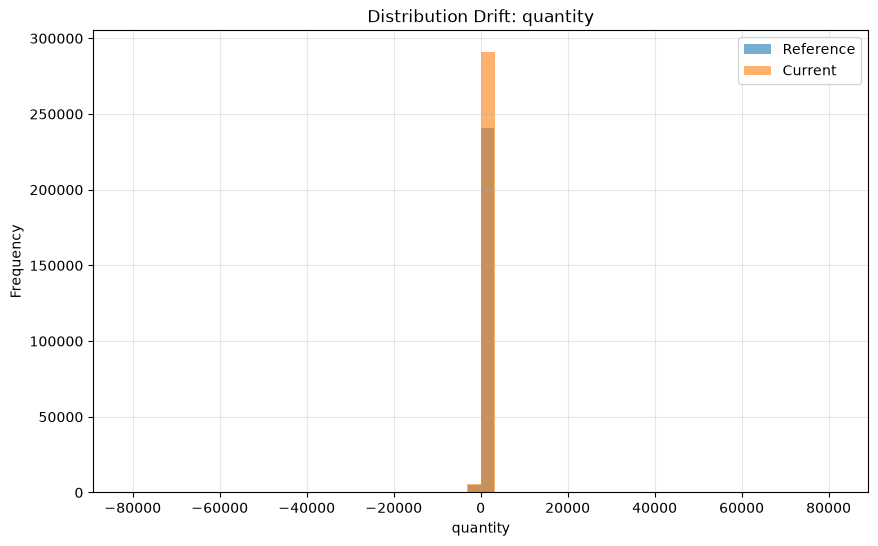

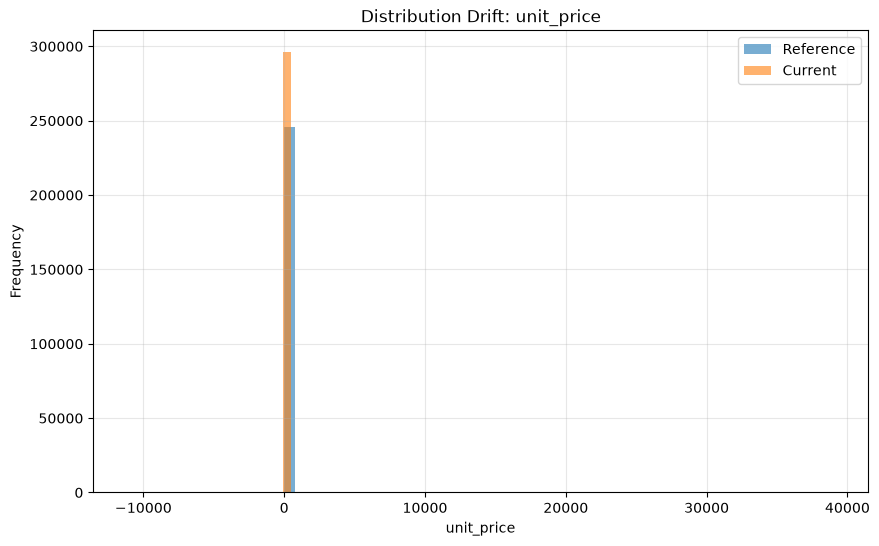

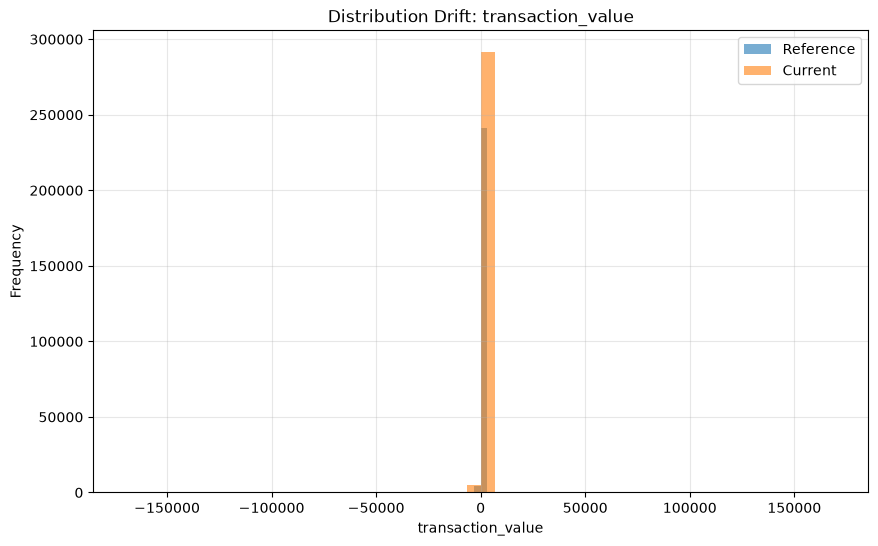

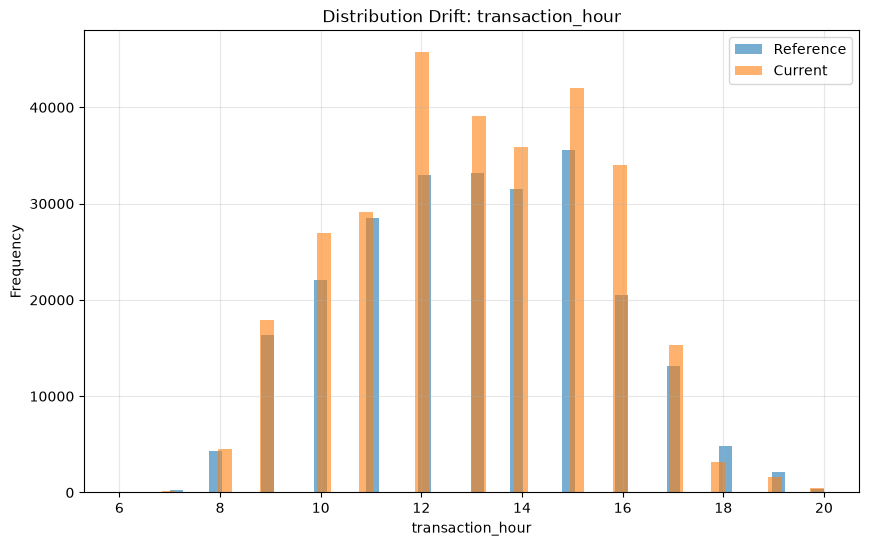

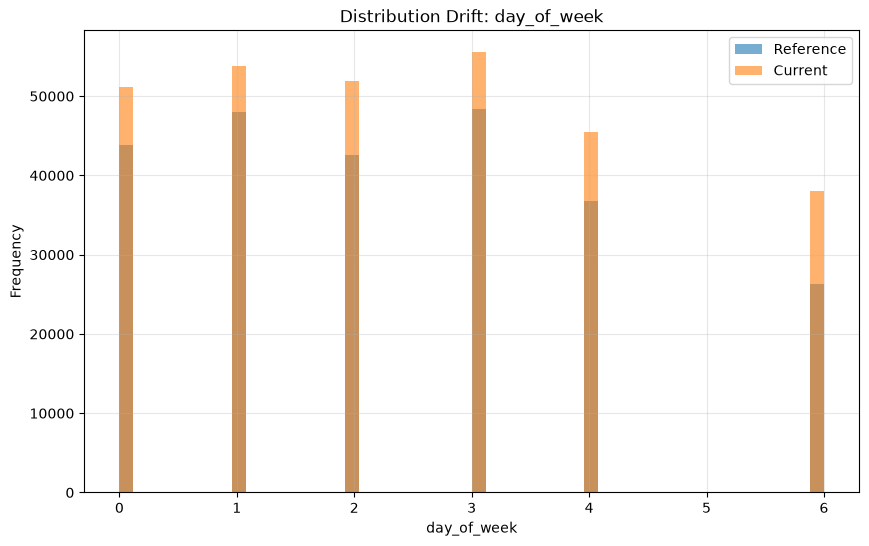

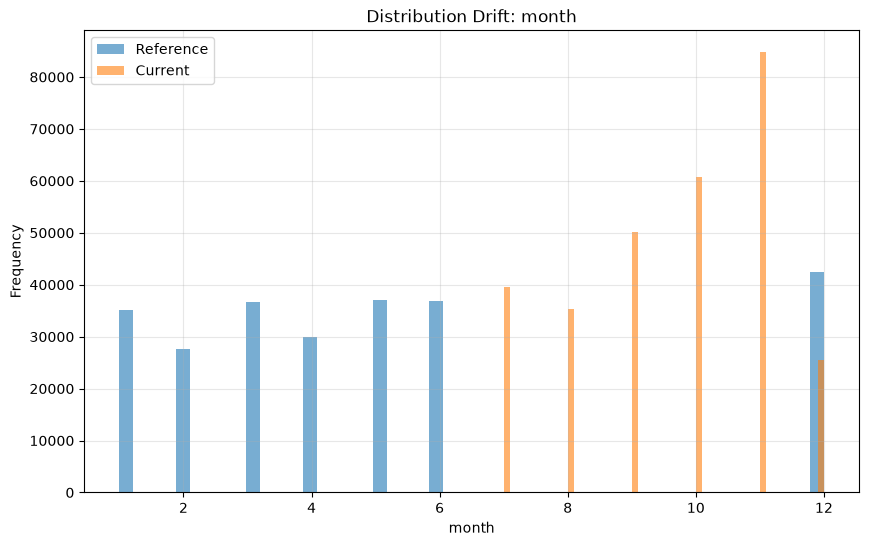

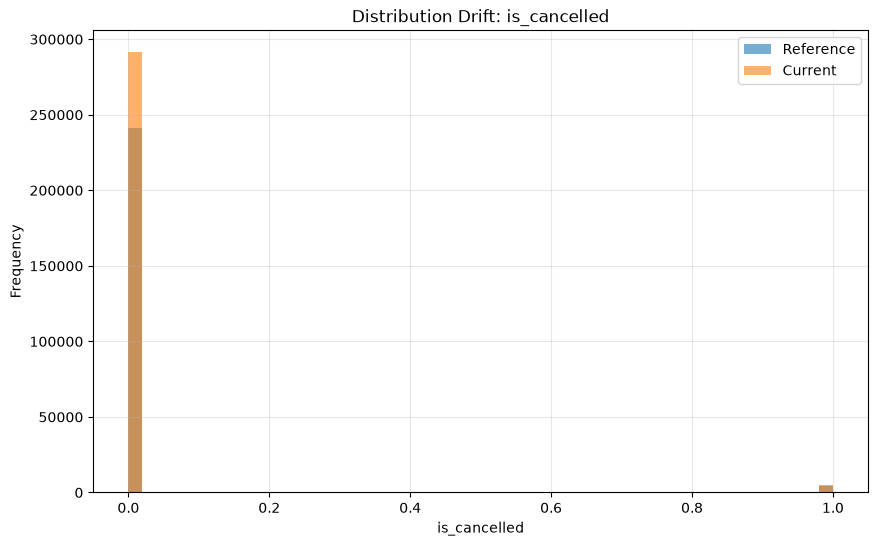


COUNTRY DISTRIBUTION CHANGES


,reference,current,absolute_difference
country,,,
United Kingdom,0.918082,0.911194,0.006887
EIRE,0.012973,0.016912,0.003939
France,0.014888,0.016540,0.001652
Switzerland,0.002989,0.004280,0.001291
Netherlands,0.005063,0.003804,0.001259
Unspecified,0.000338,0.001226,0.000889
Norway,0.001537,0.002392,0.000855
USA,0.000089,0.000909,0.000819
Australia,0.002733,0.001983,0.000750


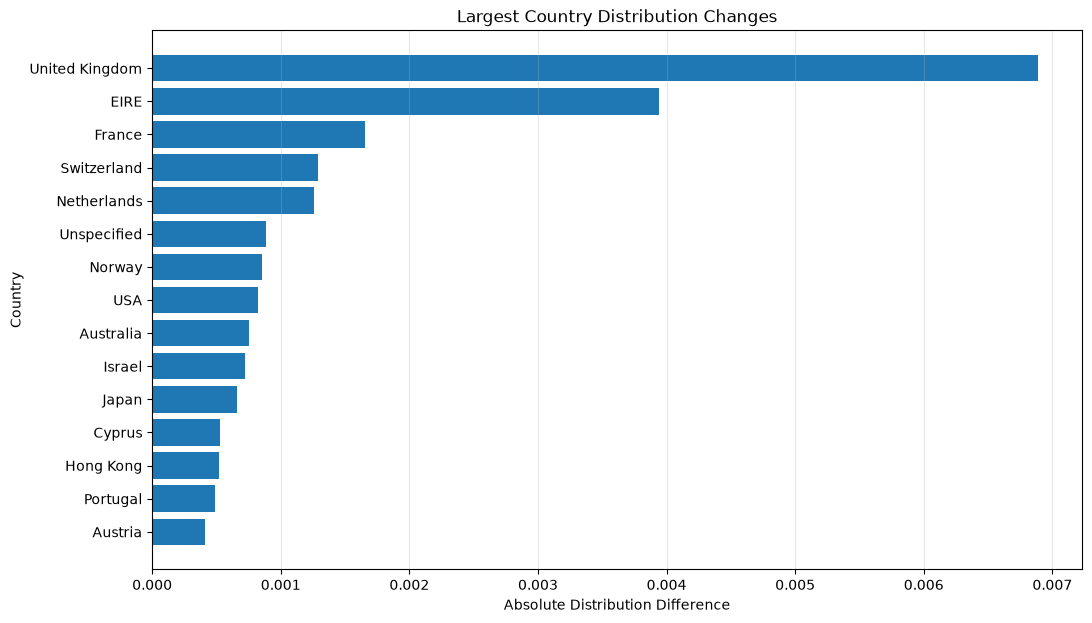


Visualization complete.


In [67]:
# ============================================
# CELL 39 — REAL DATA DRIFT VISUALIZATION
# ============================================

print("REAL-WORLD DRIFT VISUALIZATION")
print("=" * 100)


# --------------------------------------------
# 1. Numerical feature distributions
# --------------------------------------------

numerical_features = [
    "quantity",
    "unit_price",
    "transaction_value",
    "transaction_hour",
    "day_of_week",
    "month",
    "is_cancelled"
]


for feature in numerical_features:

    plt.figure(figsize=(10, 6))

    plt.hist(
        reference_monitoring_data[feature].dropna(),
        bins=50,
        alpha=0.6,
        label="Reference"
    )

    plt.hist(
        current_monitoring_data[feature].dropna(),
        bins=50,
        alpha=0.6,
        label="Current"
    )

    plt.title(
        f"Distribution Drift: {feature}"
    )

    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()


# --------------------------------------------
# 2. Country distribution comparison
# --------------------------------------------

reference_country_distribution = (
    reference_monitoring_data["country"]
    .value_counts(normalize=True)
)

current_country_distribution = (
    current_monitoring_data["country"]
    .value_counts(normalize=True)
)

country_comparison = pd.DataFrame({

    "reference": reference_country_distribution,

    "current": current_country_distribution

}).fillna(0)


country_comparison["absolute_difference"] = (
    abs(
        country_comparison["current"]
        - country_comparison["reference"]
    )
)


country_comparison = (
    country_comparison
    .sort_values(
        "absolute_difference",
        ascending=False
    )
)


print("\nCOUNTRY DISTRIBUTION CHANGES")
print("=" * 100)

display(
    country_comparison.head(15)
)


# --------------------------------------------
# 3. Plot the largest country changes
# --------------------------------------------

top_countries = (
    country_comparison
    .head(15)
    .sort_values(
        "absolute_difference"
    )
)


plt.figure(figsize=(12, 7))

plt.barh(
    top_countries.index.astype(str),
    top_countries["absolute_difference"]
)

plt.title(
    "Largest Country Distribution Changes"
)

plt.xlabel(
    "Absolute Distribution Difference"
)

plt.ylabel("Country")

plt.grid(
    axis="x",
    alpha=0.3
)

plt.show()


print("\nVisualization complete.")

In [68]:
# ============================================
# CELL 40 — DRIFT ANALYSIS SUMMARY
# ============================================

print("PRODUCTION DRIFT ANALYSIS SUMMARY")
print("=" * 100)


# --------------------------------------------
# Create analysis copy
# --------------------------------------------

drift_analysis = real_drift_report.copy()


# --------------------------------------------
# Statistical significance classification
# --------------------------------------------

drift_analysis["statistical_significance"] = (
    drift_analysis["p_value"] < 0.05
)


# --------------------------------------------
# Practical magnitude classification
# --------------------------------------------

def classify_practical_magnitude(row):
    """
    Classify whether detected drift is
    practically meaningful.

    Numerical features use normalized
    Wasserstein magnitude.

    Categorical features use TVD.
    """

    if row["status"] != "OK":
        return "INSUFFICIENT_DATA"

    if not row["drift_detected"]:
        return "NO_DRIFT"

    if row["data_type"] == "numerical":

        magnitude = row[
            "normalized_magnitude"
        ]

        if magnitude < 0.10:
            return "VERY_SMALL"

        elif magnitude < 0.50:
            return "MODERATE"

        else:
            return "LARGE"

    else:

        tvd = row["magnitude"]

        if tvd < 0.05:
            return "VERY_SMALL"

        elif tvd < 0.20:
            return "MODERATE"

        else:
            return "LARGE"


drift_analysis[
    "practical_magnitude"
] = drift_analysis.apply(
    classify_practical_magnitude,
    axis=1
)


# --------------------------------------------
# Combined interpretation
# --------------------------------------------

def classify_drift_interpretation(row):
    """
    Combine statistical significance
    and practical magnitude.

    This prevents extremely large datasets
    from making every tiny difference look
    operationally important.
    """

    if row["status"] != "OK":
        return "INSUFFICIENT_DATA"

    if not row["drift_detected"]:
        return "NO_DRIFT"

    magnitude = row[
        "practical_magnitude"
    ]

    if magnitude == "VERY_SMALL":
        return "STATISTICAL_ONLY"

    elif magnitude == "MODERATE":
        return "ACTIONABLE"

    elif magnitude == "LARGE":
        return "HIGH_IMPACT"

    return "UNKNOWN"


drift_analysis[
    "interpretation"
] = drift_analysis.apply(
    classify_drift_interpretation,
    axis=1
)


# --------------------------------------------
# Rank drift importance
# --------------------------------------------

interpretation_priority = {

    "HIGH_IMPACT": 1,

    "ACTIONABLE": 2,

    "STATISTICAL_ONLY": 3,

    "NO_DRIFT": 4,

    "INSUFFICIENT_DATA": 5,

    "UNKNOWN": 6
}


drift_analysis[
    "priority"
] = drift_analysis[
    "interpretation"
].map(
    interpretation_priority
)


drift_analysis = (
    drift_analysis
    .sort_values(
        by=[
            "priority",
            "p_value"
        ],
        ascending=[
            True,
            True
        ]
    )
    .reset_index(drop=True)
)


# --------------------------------------------
# Display complete analysis
# --------------------------------------------

analysis_columns = [

    "feature",

    "data_type",

    "test",

    "p_value",

    "magnitude",

    "normalized_magnitude",

    "drift_detected",

    "severity",

    "statistical_significance",

    "practical_magnitude",

    "interpretation",

    "status"
]


print("\nFEATURE-LEVEL DRIFT ANALYSIS")
print("=" * 100)

display(
    drift_analysis[
        analysis_columns
    ]
)


# --------------------------------------------
# Summary counts
# --------------------------------------------

print("\nDRIFT SUMMARY COUNTS")
print("=" * 100)

print(
    "\nTotal features:",
    len(drift_analysis)
)

print(
    "Statistically significant:",
    int(
        drift_analysis[
            "statistical_significance"
        ].sum()
    )
)

print(
    "Detected drift:",
    int(
        drift_analysis[
            "drift_detected"
        ].sum()
    )
)

print(
    "No drift:",
    int(
        (~drift_analysis[
            "drift_detected"
        ]).sum()
    )
)


# --------------------------------------------
# Interpretation summary
# --------------------------------------------

print("\nINTERPRETATION SUMMARY")
print("=" * 100)

interpretation_counts = (
    drift_analysis[
        "interpretation"
    ]
    .value_counts()
)

display(
    interpretation_counts
)


# --------------------------------------------
# Important features
# --------------------------------------------

important_drift = drift_analysis[
    drift_analysis[
        "interpretation"
    ].isin([
        "ACTIONABLE",
        "HIGH_IMPACT"
    ])
]


print("\nPRACTICALLY IMPORTANT DRIFT")
print("=" * 100)

if important_drift.empty:

    print(
        "No practically important drift "
        "was detected."
    )

else:

    display(
        important_drift[
            analysis_columns
        ]
    )


# --------------------------------------------
# Statistical-only drift
# --------------------------------------------

statistical_only_drift = drift_analysis[
    drift_analysis[
        "interpretation"
    ] == "STATISTICAL_ONLY"
]


print("\nSTATISTICAL-ONLY DRIFT")
print("=" * 100)

if statistical_only_drift.empty:

    print(
        "No statistical-only drift detected."
    )

else:

    display(
        statistical_only_drift[
            analysis_columns
        ]
    )


print("\n" + "=" * 100)
print("DRIFT ANALYSIS COMPLETE")
print("=" * 100)

PRODUCTION DRIFT ANALYSIS SUMMARY

FEATURE-LEVEL DRIFT ANALYSIS


,feature,data_type,test,p_value,magnitude,normalized_magnitude,drift_detected,severity,statistical_significance,practical_magnitude,interpretation,status
0,month,numerical,KS Test,0.000000e+00,4.794144,1.348749,True,HIGH,True,LARGE,HIGH_IMPACT,OK
1,unit_price,numerical,KS Test,0.000000e+00,0.988406,0.008335,True,LOW,True,VERY_SMALL,STATISTICAL_ONLY,OK
2,country,categorical,Chi-Square Test,8.365422e-247,0.012131,NaN,True,LOW,True,VERY_SMALL,STATISTICAL_ONLY,OK
3,transaction_value,numerical,KS Test,4.671293e-85,2.179618,0.008051,True,LOW,True,VERY_SMALL,STATISTICAL_ONLY,OK
4,day_of_week,numerical,KS Test,4.207193e-78,0.109756,0.060620,True,LOW,True,VERY_SMALL,STATISTICAL_ONLY,OK
5,quantity,numerical,KS Test,3.375132e-74,0.958791,0.004348,True,LOW,True,VERY_SMALL,STATISTICAL_ONLY,OK
6,transaction_hour,numerical,KS Test,8.822192e-73,0.118293,0.047728,True,LOW,True,VERY_SMALL,STATISTICAL_ONLY,OK
7,is_cancelled,numerical,KS Test,6.057981e-01,0.002080,0.015528,False,NO_DRIFT,False,NO_DRIFT,NO_DRIFT,OK



DRIFT SUMMARY COUNTS

Total features: 8
Statistically significant: 7
Detected drift: 7
No drift: 1

INTERPRETATION SUMMARY


interpretation
STATISTICAL_ONLY    6
HIGH_IMPACT         1
NO_DRIFT            1
Name: count, dtype: int64


PRACTICALLY IMPORTANT DRIFT


,feature,data_type,test,p_value,magnitude,normalized_magnitude,drift_detected,severity,statistical_significance,practical_magnitude,interpretation,status
0,month,numerical,KS Test,0.0,4.794144,1.348749,True,HIGH,True,LARGE,HIGH_IMPACT,OK



STATISTICAL-ONLY DRIFT


,feature,data_type,test,p_value,magnitude,normalized_magnitude,drift_detected,severity,statistical_significance,practical_magnitude,interpretation,status
1,unit_price,numerical,KS Test,0.000000e+00,0.988406,0.008335,True,LOW,True,VERY_SMALL,STATISTICAL_ONLY,OK
2,country,categorical,Chi-Square Test,8.365422e-247,0.012131,NaN,True,LOW,True,VERY_SMALL,STATISTICAL_ONLY,OK
3,transaction_value,numerical,KS Test,4.671293e-85,2.179618,0.008051,True,LOW,True,VERY_SMALL,STATISTICAL_ONLY,OK
4,day_of_week,numerical,KS Test,4.207193e-78,0.109756,0.060620,True,LOW,True,VERY_SMALL,STATISTICAL_ONLY,OK
5,quantity,numerical,KS Test,3.375132e-74,0.958791,0.004348,True,LOW,True,VERY_SMALL,STATISTICAL_ONLY,OK
6,transaction_hour,numerical,KS Test,8.822192e-73,0.118293,0.047728,True,LOW,True,VERY_SMALL,STATISTICAL_ONLY,OK



DRIFT ANALYSIS COMPLETE


In [69]:
# ============================================
# CELL 41 — MULTIPLE TESTING CORRECTION
# ============================================

from scipy.stats import false_discovery_control


print("MULTIPLE TESTING CORRECTION")
print("=" * 100)


# --------------------------------------------
# Create a copy of the drift analysis
# --------------------------------------------

fdr_analysis = drift_analysis.copy()


# --------------------------------------------
# Extract valid p-values
# --------------------------------------------

valid_p_values = (
    fdr_analysis["p_value"]
    .dropna()
)


# --------------------------------------------
# Benjamini-Hochberg FDR correction
# --------------------------------------------

adjusted_p_values = false_discovery_control(
    valid_p_values,
    method="bh"
)


# --------------------------------------------
# Store adjusted p-values
# --------------------------------------------

fdr_analysis[
    "adjusted_p_value"
] = np.nan

fdr_analysis.loc[
    valid_p_values.index,
    "adjusted_p_value"
] = adjusted_p_values


# --------------------------------------------
# Determine FDR significance
# --------------------------------------------

fdr_analysis[
    "fdr_significant"
] = (
    fdr_analysis[
        "adjusted_p_value"
    ] < 0.05
)


# --------------------------------------------
# Compare original vs adjusted significance
# --------------------------------------------

fdr_analysis[
    "significance_changed"
] = (
    fdr_analysis[
        "statistical_significance"
    ]
    !=
    fdr_analysis[
        "fdr_significant"
    ]
)


# --------------------------------------------
# Display results
# --------------------------------------------

fdr_columns = [

    "feature",

    "p_value",

    "adjusted_p_value",

    "statistical_significance",

    "fdr_significant",

    "significance_changed",

    "magnitude",

    "normalized_magnitude",

    "practical_magnitude",

    "interpretation"
]


print("\nFDR-CORRECTED DRIFT RESULTS")
print("=" * 100)

display(
    fdr_analysis[
        fdr_columns
    ]
)


# --------------------------------------------
# Summary
# --------------------------------------------

original_significant_count = int(
    fdr_analysis[
        "statistical_significance"
    ].sum()
)

fdr_significant_count = int(
    fdr_analysis[
        "fdr_significant"
    ].sum()
)


print("\nSIGNIFICANCE SUMMARY")
print("=" * 100)

print(
    "\nOriginal statistically significant:",
    original_significant_count
)

print(
    "FDR-adjusted significant:",
    fdr_significant_count
)

print(
    "Significance classifications changed:",
    int(
        fdr_analysis[
            "significance_changed"
        ].sum()
    )
)


# --------------------------------------------
# Final interpretation
# --------------------------------------------

print("\nFINAL FDR INTERPRETATION")
print("=" * 100)

if fdr_significant_count == 0:

    print(
        "No features remain statistically "
        "significant after FDR correction."
    )

else:

    print(
        f"{fdr_significant_count} feature(s) "
        "remain statistically significant "
        "after FDR correction."
    )


print("\n" + "=" * 100)
print("MULTIPLE TESTING ANALYSIS COMPLETE")
print("=" * 100)

MULTIPLE TESTING CORRECTION

FDR-CORRECTED DRIFT RESULTS


,feature,p_value,adjusted_p_value,statistical_significance,fdr_significant,significance_changed,magnitude,normalized_magnitude,practical_magnitude,interpretation
0,month,0.000000e+00,0.000000e+00,True,True,False,4.794144,1.348749,LARGE,HIGH_IMPACT
1,unit_price,0.000000e+00,0.000000e+00,True,True,False,0.988406,0.008335,VERY_SMALL,STATISTICAL_ONLY
2,country,8.365422e-247,2.230779e-246,True,True,False,0.012131,NaN,VERY_SMALL,STATISTICAL_ONLY
3,transaction_value,4.671293e-85,9.342587e-85,True,True,False,2.179618,0.008051,VERY_SMALL,STATISTICAL_ONLY
4,day_of_week,4.207193e-78,6.731509e-78,True,True,False,0.109756,0.060620,VERY_SMALL,STATISTICAL_ONLY
5,quantity,3.375132e-74,4.500175e-74,True,True,False,0.958791,0.004348,VERY_SMALL,STATISTICAL_ONLY
6,transaction_hour,8.822192e-73,1.008251e-72,True,True,False,0.118293,0.047728,VERY_SMALL,STATISTICAL_ONLY
7,is_cancelled,6.057981e-01,6.057981e-01,False,False,False,0.002080,0.015528,NO_DRIFT,NO_DRIFT



SIGNIFICANCE SUMMARY

Original statistically significant: 7
FDR-adjusted significant: 7
Significance classifications changed: 0

FINAL FDR INTERPRETATION
7 feature(s) remain statistically significant after FDR correction.

MULTIPLE TESTING ANALYSIS COMPLETE


In [70]:
# ============================================
# CELL 42 — FINAL PRODUCTION DRIFT REPORT
# ============================================

print("FINAL PRODUCTION DRIFT REPORT")
print("=" * 110)


# --------------------------------------------
# Start from FDR analysis
# --------------------------------------------

final_report = fdr_analysis.copy()


# --------------------------------------------
# Create final drift decision
# --------------------------------------------

def determine_final_decision(row):
    """
    Produce the final monitoring decision.

    Rules:

    1. Insufficient data
       -> INSUFFICIENT_DATA

    2. No FDR-significant drift
       -> NO_DRIFT

    3. FDR-significant + very small magnitude
       -> MONITOR

    4. FDR-significant + moderate magnitude
       -> INVESTIGATE

    5. FDR-significant + large magnitude
       -> ALERT
    """

    if row["status"] != "OK":
        return "INSUFFICIENT_DATA"

    if not row["fdr_significant"]:
        return "NO_DRIFT"

    if row["practical_magnitude"] == "VERY_SMALL":
        return "MONITOR"

    elif row["practical_magnitude"] == "MODERATE":
        return "INVESTIGATE"

    elif row["practical_magnitude"] == "LARGE":
        return "ALERT"

    return "UNKNOWN"


final_report[
    "final_decision"
] = final_report.apply(
    determine_final_decision,
    axis=1
)


# --------------------------------------------
# Assign operational priority
# --------------------------------------------

decision_priority = {

    "ALERT": 1,

    "INVESTIGATE": 2,

    "MONITOR": 3,

    "NO_DRIFT": 4,

    "INSUFFICIENT_DATA": 5,

    "UNKNOWN": 6
}


final_report[
    "priority"
] = final_report[
    "final_decision"
].map(
    decision_priority
)


final_report = (
    final_report
    .sort_values(
        by=[
            "priority",
            "adjusted_p_value"
        ],
        ascending=[
            True,
            True
        ]
    )
    .reset_index(drop=True)
)


# --------------------------------------------
# Select final production columns
# --------------------------------------------

final_report_columns = [

    "feature",

    "data_type",

    "test",

    "p_value",

    "adjusted_p_value",

    "magnitude",

    "normalized_magnitude",

    "drift_detected",

    "severity",

    "fdr_significant",

    "practical_magnitude",

    "interpretation",

    "final_decision",

    "reference_sample_size",

    "current_sample_size",

    "reference_missing_rate",

    "current_missing_rate",

    "missing_rate_difference",

    "status"
]


final_report = final_report[
    final_report_columns
]


# --------------------------------------------
# Display final report
# --------------------------------------------

print("\nFEATURE-LEVEL PRODUCTION REPORT")
print("=" * 110)

display(
    final_report
)


# --------------------------------------------
# Operational summary
# --------------------------------------------

print("\nOPERATIONAL SUMMARY")
print("=" * 110)

decision_counts = (
    final_report[
        "final_decision"
    ]
    .value_counts()
)


display(
    decision_counts
)


# --------------------------------------------
# Count each decision type
# --------------------------------------------

alert_count = int(
    (
        final_report[
            "final_decision"
        ] == "ALERT"
    ).sum()
)

investigate_count = int(
    (
        final_report[
            "final_decision"
        ] == "INVESTIGATE"
    ).sum()
)

monitor_count = int(
    (
        final_report[
            "final_decision"
        ] == "MONITOR"
    ).sum()
)

no_drift_count = int(
    (
        final_report[
            "final_decision"
        ] == "NO_DRIFT"
    ).sum()
)


print(
    "\nALERT:",
    alert_count
)

print(
    "INVESTIGATE:",
    investigate_count
)

print(
    "MONITOR:",
    monitor_count
)

print(
    "NO_DRIFT:",
    no_drift_count
)


# --------------------------------------------
# Critical alerts
# --------------------------------------------

critical_alerts = final_report[
    final_report[
        "final_decision"
    ] == "ALERT"
]


print("\nCRITICAL DRIFT ALERTS")
print("=" * 110)


if critical_alerts.empty:

    print(
        "No high-impact drift alerts detected."
    )

else:

    display(
        critical_alerts[
            [
                "feature",
                "adjusted_p_value",
                "magnitude",
                "normalized_magnitude",
                "severity",
                "final_decision"
            ]
        ]
    )


# --------------------------------------------
# Features requiring monitoring
# --------------------------------------------

monitor_features = final_report[
    final_report[
        "final_decision"
    ] == "MONITOR"
]


print("\nFEATURES REQUIRING MONITORING")
print("=" * 110)


if monitor_features.empty:

    print(
        "No features require monitoring."
    )

else:

    display(
        monitor_features[
            [
                "feature",
                "adjusted_p_value",
                "magnitude",
                "normalized_magnitude",
                "practical_magnitude",
                "final_decision"
            ]
        ]
    )


# --------------------------------------------
# Overall system status
# --------------------------------------------

if alert_count > 0:

    overall_status = "ALERT"

elif investigate_count > 0:

    overall_status = "INVESTIGATE"

elif monitor_count > 0:

    overall_status = "MONITOR"

else:

    overall_status = "HEALTHY"


print("\nOVERALL DATASET STATUS")
print("=" * 110)

print(
    f"STATUS: {overall_status}"
)


print("\n" + "=" * 110)
print("FINAL PRODUCTION DRIFT ANALYSIS COMPLETE")
print("=" * 110)

FINAL PRODUCTION DRIFT REPORT

FEATURE-LEVEL PRODUCTION REPORT


,feature,data_type,test,p_value,adjusted_p_value,magnitude,normalized_magnitude,drift_detected,severity,fdr_significant,practical_magnitude,interpretation,final_decision,reference_sample_size,current_sample_size,reference_missing_rate,current_missing_rate,missing_rate_difference,status
0,month,numerical,KS Test,0.000000e+00,0.000000e+00,4.794144,1.348749,True,HIGH,True,LARGE,HIGH_IMPACT,ALERT,245903,296006,0.0,0.0,0.0,OK
1,unit_price,numerical,KS Test,0.000000e+00,0.000000e+00,0.988406,0.008335,True,LOW,True,VERY_SMALL,STATISTICAL_ONLY,MONITOR,245903,296006,0.0,0.0,0.0,OK
2,country,categorical,Chi-Square Test,8.365422e-247,2.230779e-246,0.012131,NaN,True,LOW,True,VERY_SMALL,STATISTICAL_ONLY,MONITOR,245903,296006,0.0,0.0,0.0,OK
3,transaction_value,numerical,KS Test,4.671293e-85,9.342587e-85,2.179618,0.008051,True,LOW,True,VERY_SMALL,STATISTICAL_ONLY,MONITOR,245903,296006,0.0,0.0,0.0,OK
4,day_of_week,numerical,KS Test,4.207193e-78,6.731509e-78,0.109756,0.060620,True,LOW,True,VERY_SMALL,STATISTICAL_ONLY,MONITOR,245903,296006,0.0,0.0,0.0,OK
5,quantity,numerical,KS Test,3.375132e-74,4.500175e-74,0.958791,0.004348,True,LOW,True,VERY_SMALL,STATISTICAL_ONLY,MONITOR,245903,296006,0.0,0.0,0.0,OK
6,transaction_hour,numerical,KS Test,8.822192e-73,1.008251e-72,0.118293,0.047728,True,LOW,True,VERY_SMALL,STATISTICAL_ONLY,MONITOR,245903,296006,0.0,0.0,0.0,OK
7,is_cancelled,numerical,KS Test,6.057981e-01,6.057981e-01,0.002080,0.015528,False,NO_DRIFT,False,NO_DRIFT,NO_DRIFT,NO_DRIFT,245903,296006,0.0,0.0,0.0,OK



OPERATIONAL SUMMARY


final_decision
MONITOR     6
ALERT       1
NO_DRIFT    1
Name: count, dtype: int64


ALERT: 1
INVESTIGATE: 0
MONITOR: 6
NO_DRIFT: 1

CRITICAL DRIFT ALERTS


,feature,adjusted_p_value,magnitude,normalized_magnitude,severity,final_decision
0,month,0.0,4.794144,1.348749,HIGH,ALERT



FEATURES REQUIRING MONITORING


,feature,adjusted_p_value,magnitude,normalized_magnitude,practical_magnitude,final_decision
1,unit_price,0.000000e+00,0.988406,0.008335,VERY_SMALL,MONITOR
2,country,2.230779e-246,0.012131,NaN,VERY_SMALL,MONITOR
3,transaction_value,9.342587e-85,2.179618,0.008051,VERY_SMALL,MONITOR
4,day_of_week,6.731509e-78,0.109756,0.060620,VERY_SMALL,MONITOR
5,quantity,4.500175e-74,0.958791,0.004348,VERY_SMALL,MONITOR
6,transaction_hour,1.008251e-72,0.118293,0.047728,VERY_SMALL,MONITOR



OVERALL DATASET STATUS
STATUS: ALERT

FINAL PRODUCTION DRIFT ANALYSIS COMPLETE


In [71]:
# ============================================
# CELL 43 — EXPORT PRODUCTION REPORT
# ============================================

from pathlib import Path
import json


print("EXPORTING PRODUCTION DRIFT REPORT")
print("=" * 100)


# --------------------------------------------
# Create reports directory
# --------------------------------------------

reports_directory = Path("../reports")

reports_directory.mkdir(
    parents=True,
    exist_ok=True
)


# --------------------------------------------
# Export CSV
# --------------------------------------------

csv_path = (
    reports_directory
    / "final_drift_report.csv"
)


final_report.to_csv(
    csv_path,
    index=False
)


print("\nCSV report created:")
print(
    csv_path.resolve()
)


# --------------------------------------------
# Prepare JSON-compatible report
# --------------------------------------------

json_report = final_report.copy()


# Replace NaN values because standard JSON
# does not support NaN reliably.

json_report = json_report.replace(
    {
        np.nan: None
    }
)


# Convert DataFrame to list of dictionaries

json_records = (
    json_report
    .to_dict(
        orient="records"
    )
)


# --------------------------------------------
# Create complete JSON report
# --------------------------------------------

report_metadata = {

    "report_type":
        "Automated Data Drift Detection",

    "dataset":
        "UCI Online Retail",

    "reference_rows":
        int(
            len(
                reference_monitoring_data
            )
        ),

    "current_rows":
        int(
            len(
                current_monitoring_data
            )
        ),

    "number_of_features":
        int(
            len(final_report)
        ),

    "alert_count":
        int(alert_count),

    "investigate_count":
        int(investigate_count),

    "monitor_count":
        int(monitor_count),

    "no_drift_count":
        int(no_drift_count),

    "overall_status":
        overall_status,

    "features":
        json_records
}


json_path = (
    reports_directory
    / "final_drift_report.json"
)


with open(
    json_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        report_metadata,
        file,
        indent=4,
        allow_nan=False
    )


print("\nJSON report created:")
print(
    json_path.resolve()
)


# --------------------------------------------
# Verify files
# --------------------------------------------

print("\nEXPORTED FILES")
print("=" * 100)

print(
    "CSV exists:",
    csv_path.exists()
)

print(
    "JSON exists:",
    json_path.exists()
)


print("\nCSV size:")
print(
    f"{csv_path.stat().st_size:,} bytes"
)


print("\nJSON size:")
print(
    f"{json_path.stat().st_size:,} bytes"
)


# --------------------------------------------
# Preview exported CSV
# --------------------------------------------

print("\nCSV PREVIEW")
print("=" * 100)

exported_csv = pd.read_csv(
    csv_path
)

display(
    exported_csv.head()
)


print("\n" + "=" * 100)
print("REPORT EXPORT COMPLETE")
print("=" * 100)

EXPORTING PRODUCTION DRIFT REPORT

CSV report created:
/home/mayank/projects/automated-data-drift-detector/reports/final_drift_report.csv

JSON report created:
/home/mayank/projects/automated-data-drift-detector/reports/final_drift_report.json

EXPORTED FILES
CSV exists: True
JSON exists: True

CSV size:
1,727 bytes

JSON size:
6,785 bytes

CSV PREVIEW


,feature,data_type,test,p_value,adjusted_p_value,magnitude,normalized_magnitude,drift_detected,severity,fdr_significant,practical_magnitude,interpretation,final_decision,reference_sample_size,current_sample_size,reference_missing_rate,current_missing_rate,missing_rate_difference,status
0,month,numerical,KS Test,0.000000e+00,0.000000e+00,4.794144,1.348749,True,HIGH,True,LARGE,HIGH_IMPACT,ALERT,245903,296006,0.0,0.0,0.0,OK
1,unit_price,numerical,KS Test,0.000000e+00,0.000000e+00,0.988406,0.008335,True,LOW,True,VERY_SMALL,STATISTICAL_ONLY,MONITOR,245903,296006,0.0,0.0,0.0,OK
2,country,categorical,Chi-Square Test,8.365422e-247,2.230779e-246,0.012131,NaN,True,LOW,True,VERY_SMALL,STATISTICAL_ONLY,MONITOR,245903,296006,0.0,0.0,0.0,OK
3,transaction_value,numerical,KS Test,4.671293e-85,9.342587e-85,2.179618,0.008051,True,LOW,True,VERY_SMALL,STATISTICAL_ONLY,MONITOR,245903,296006,0.0,0.0,0.0,OK
4,day_of_week,numerical,KS Test,4.207193e-78,6.731509e-78,0.109756,0.060620,True,LOW,True,VERY_SMALL,STATISTICAL_ONLY,MONITOR,245903,296006,0.0,0.0,0.0,OK



REPORT EXPORT COMPLETE


In [72]:
# ============================================
# CELL 44 — FINAL NOTEBOOK VALIDATION
# ============================================

print("FINAL NOTEBOOK VALIDATION")
print("=" * 100)


# --------------------------------------------
# 1. Validate production report
# --------------------------------------------

assert not final_report.empty, (
    "Final report is empty."
)

assert len(final_report) == 8, (
    "Expected 8 monitored features."
)


# --------------------------------------------
# 2. Validate required columns
# --------------------------------------------

required_columns = [

    "feature",
    "data_type",
    "test",
    "p_value",
    "adjusted_p_value",
    "magnitude",
    "normalized_magnitude",
    "drift_detected",
    "severity",
    "fdr_significant",
    "practical_magnitude",
    "interpretation",
    "final_decision",
    "reference_sample_size",
    "current_sample_size",
    "reference_missing_rate",
    "current_missing_rate",
    "missing_rate_difference",
    "status"
]


missing_required_columns = [
    column
    for column in required_columns
    if column not in final_report.columns
]


assert not missing_required_columns, (
    "Missing required report columns: "
    f"{missing_required_columns}"
)


print("\n✓ Report structure validated")


# --------------------------------------------
# 3. Validate monitored features
# --------------------------------------------

expected_features = {
    "quantity",
    "unit_price",
    "transaction_value",
    "transaction_hour",
    "day_of_week",
    "month",
    "is_cancelled",
    "country"
}


actual_features = set(
    final_report["feature"]
)


assert actual_features == expected_features, (
    "Feature set does not match expected features."
)


print("✓ Feature set validated")


# --------------------------------------------
# 4. Validate reference/current sample sizes
# --------------------------------------------

assert (
    final_report[
        "reference_sample_size"
    ] == len(reference_monitoring_data)
).all()


assert (
    final_report[
        "current_sample_size"
    ] == len(current_monitoring_data)
).all()


print("✓ Sample sizes validated")


# --------------------------------------------
# 5. Validate FDR results
# --------------------------------------------

assert (
    final_report["adjusted_p_value"]
    .notna()
).all()


print("✓ FDR-adjusted p-values validated")


# --------------------------------------------
# 6. Validate final decisions
# --------------------------------------------

allowed_decisions = {
    "ALERT",
    "INVESTIGATE",
    "MONITOR",
    "NO_DRIFT",
    "INSUFFICIENT_DATA",
    "UNKNOWN"
}


actual_decisions = set(
    final_report[
        "final_decision"
    ]
)


assert actual_decisions.issubset(
    allowed_decisions
), (
    "Unexpected final decision detected."
)


print("✓ Final decisions validated")


# --------------------------------------------
# 7. Validate exported files
# --------------------------------------------

csv_path = Path(
    "../reports/final_drift_report.csv"
)

json_path = Path(
    "../reports/final_drift_report.json"
)


assert csv_path.exists(), (
    "CSV report was not found."
)

assert json_path.exists(), (
    "JSON report was not found."
)


print("✓ Exported files validated")


# --------------------------------------------
# 8. Validate exported CSV
# --------------------------------------------

exported_csv = pd.read_csv(
    csv_path
)


assert len(exported_csv) == len(
    final_report
)


assert set(
    exported_csv["feature"]
) == expected_features


print("✓ Exported CSV validated")


# --------------------------------------------
# 9. Validate exported JSON
# --------------------------------------------

with open(
    json_path,
    "r",
    encoding="utf-8"
) as file:

    exported_json = json.load(file)


assert (
    exported_json["dataset"]
    == "UCI Online Retail"
)


assert (
    exported_json["number_of_features"]
    == 8
)


assert (
    len(exported_json["features"])
    == 8
)


print("✓ Exported JSON validated")


# --------------------------------------------
# 10. Validate overall status
# --------------------------------------------

assert overall_status in {
    "HEALTHY",
    "MONITOR",
    "INVESTIGATE",
    "ALERT"
}


print("✓ Overall system status validated")


# --------------------------------------------
# FINAL RESULT
# --------------------------------------------

print("\n" + "=" * 100)

print("ALL VALIDATION CHECKS PASSED")

print("=" * 100)

print("\nProject Status:")
print(
    "✓ Synthetic data testing"
)

print(
    "✓ Statistical drift detection"
)

print(
    "✓ Numerical drift analysis"
)

print(
    "✓ Categorical drift analysis"
)

print(
    "✓ Missing-value handling"
)

print(
    "✓ Schema validation"
)

print(
    "✓ Practical drift magnitude"
)

print(
    "✓ Multiple-testing correction"
)

print(
    "✓ Production decision engine"
)

print(
    "✓ CSV report generation"
)

print(
    "✓ JSON report generation"
)

print(
    "✓ End-to-end validation"
)

print("\n" + "=" * 100)
print("NOTEBOOK PIPELINE VALIDATION COMPLETE")
print("=" * 100)

FINAL NOTEBOOK VALIDATION

✓ Report structure validated
✓ Feature set validated
✓ Sample sizes validated
✓ FDR-adjusted p-values validated
✓ Final decisions validated
✓ Exported files validated
✓ Exported CSV validated
✓ Exported JSON validated
✓ Overall system status validated

ALL VALIDATION CHECKS PASSED

Project Status:
✓ Synthetic data testing
✓ Statistical drift detection
✓ Numerical drift analysis
✓ Categorical drift analysis
✓ Missing-value handling
✓ Schema validation
✓ Practical drift magnitude
✓ Multiple-testing correction
✓ Production decision engine
✓ CSV report generation
✓ JSON report generation
✓ End-to-end validation

NOTEBOOK PIPELINE VALIDATION COMPLETE
